## Part A: Data Preparation and Exploration

In [1]:
from pathlib import Path
import platform
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import math
import pickle
import random
import re
import unicodedata
import zipfile
from collections import Counter
from urllib.parse import unquote_plus
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
RANDOM_SEED = 455
TEST_SIZE = 0.20
MIN_PLAYLIST_LENGTH = 2 #Did not consider playlists with 1 song only

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DRIVE_ROOT = Path('/content/drive/MyDrive')
PROJECT_DIR = DRIVE_ROOT / 'CS455' / 'HW1'
ZIP_PATH = PROJECT_DIR / 'Data-20260322T230625Z-1-001.zip'

ARTIFACT_DIR = PROJECT_DIR / 'artifacts' / 'part_a'
FIGURE_DIR = ARTIFACT_DIR / 'figures'
TABLE_DIR = ARTIFACT_DIR / 'tables'
CACHE_DIR = ARTIFACT_DIR / 'cache'

for directory in (ARTIFACT_DIR, FIGURE_DIR, TABLE_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

assert ZIP_PATH.exists(), f'Update ZIP_PATH first. File not found: {ZIP_PATH}'

In [4]:
"""
Raw Data Inspection

This cell lists the files inside the zip archive and shows a short sample from
both `playlist.idomaar` and `tracks.idomaar` before I do any bulk parsing.
"""

def iter_zip_lines(zip_path, member_name, encoding='utf-8'):
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(member_name) as handle:
            for raw_line in handle:
                yield raw_line.decode(encoding).rstrip('\n')


with zipfile.ZipFile(ZIP_PATH) as zf:
    members_df = pd.DataFrame(
        [{'file': info.filename, 'size_bytes': info.file_size} for info in zf.infolist()]
    )

display(members_df)

for member_name in ('Data/playlist.idomaar', 'Data/tracks.idomaar'):
    print(f'\n=== Sample from {member_name} ===')
    for idx, sample_line in zip(range(2), iter_zip_lines(ZIP_PATH, member_name)):
        preview = sample_line[:700]
        suffix = '...' if len(sample_line) > 700 else ''
        print(preview + suffix)

,file,size_bytes
0,Data/tracks.idomaar,1260315949
1,Data/users.idomaar,6620935
2,Data/albums.idomaar,20890931
3,Data/tags.idomaar,24467803
4,Data/persons.idomaar,43832969
5,Data/playlist.idomaar,56245795



=== Sample from Data/playlist.idomaar ===
playlist	0	1216545588	{"ID":2973549,"Title":"my_favorites","numtracks":27,"duration":6522}	{"subjects":[{"type":"user","id":41504}],"objects":[{"type":"track","id":3006631},{"type":"track","id":1885124},{"type":"track","id":2548942},{"type":"track","id":1350486},{"type":"track","id":3734368},{"type":"track","id":3559010},{"type":"track","id":1843196},{"type":"track","id":1480428},{"type":"track","id":3287322},{"type":"track","id":2289919},{"type":"track","id":2279338},{"type":"track","id":2279191},{"type":"track","id":341161},{"type":"track","id":2949622},{"type":"track","id":1210794},{"type":"track","id":3221713},{"type":"track","id":2288588},{"type":"track","id":2983307},{"type":"track","i...
playlist	1	1249326867	{"ID":5429703,"Title":"","numtracks":9,"duration":2650}	{"subjects":[{"type":"user","id":41504}],"objects":[{"type":"track","id":2807573},{"type":"track","id":2807606},{"type":"track","id":1119655},{"type":"track","id":1378148},{"t

In [5]:
"""
Helper Functions
"""

def split_idomaar_line(line):
    parts = line.split('\t', 4)
    if len(parts) < 5:
        raise ValueError(f'Expected at least 5 tab-separated fields, got {len(parts)}')
    return parts


def normalize_text(text):
    text = unicodedata.normalize('NFKC', text or '').lower()
    text = text.replace('\u200b', ' ')
    text = text.replace('__', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def to_token_component(text):
    text = normalize_text(text)
    text = re.sub(r'\s+', '_', text).strip('_')
    return text


def parse_track_name(name_value):
    decoded_name = unquote_plus(name_value or '')
    if '/_/' not in decoded_name:
        return None

    artist_raw, title_raw = decoded_name.split('/_/', 1)
    artist = normalize_text(artist_raw)
    title = normalize_text(title_raw)

    if not artist or not title:
        return None

    artist_token = to_token_component(artist)
    title_token = to_token_component(title)

    return {
        'artist': artist,
        'title': title,
        'token': f'{artist_token}__{title_token}',
        'decoded_name': decoded_name,
    }


def save_pickle(obj, path):
    with open(path, 'wb') as handle:
        pickle.dump(obj, handle)

def load_pickle(path):
    with open(path, 'rb') as handle:
        return pickle.load(handle)


def save_json(obj, path):
    with open(path, 'w', encoding='utf-8') as handle:
        json.dump(obj, handle, ensure_ascii=False, indent=2)


def save_jsonl(records, path):
    with open(path, 'w', encoding='utf-8') as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + '\n')

In [6]:
#A.1 Data Loading and Preprocessing
"""
Parse Playlists

Extracted ordered track IDs, retained basic playlist metadata,
and dropped raw playlists shorter than 2 tracks.
"""

playlist_records = []
referenced_track_ids = set()
playlist_stats = Counter()

for line_number, line in enumerate(iter_zip_lines(ZIP_PATH, 'Data/playlist.idomaar'), start=1):
    try:
        fields = split_idomaar_line(line)
        playlist_id = int(fields[1])
        timestamp = int(fields[2])
        playlist_meta = json.loads(fields[3])
        objects_meta = json.loads(fields[4])

        track_ids = [
            int(item['id'])
            for item in objects_meta.get('objects', [])
            if item.get('type') == 'track' and item.get('id') is not None
        ]

        if len(track_ids) < MIN_PLAYLIST_LENGTH:
            playlist_stats['dropped_short_raw_playlists'] += 1
            continue

        record = {
            'playlist_id': playlist_id,
            'timestamp': timestamp,
            'title': unquote_plus(str(playlist_meta.get('Title', '') or '')),
            'numtracks_meta': playlist_meta.get('numtracks'),
            'duration_meta': playlist_meta.get('duration'),
            'track_ids': track_ids,
            'raw_length': len(track_ids),
        }

        playlist_records.append(record)
        referenced_track_ids.update(track_ids)
        playlist_stats['kept_raw_playlists'] += 1
    except Exception as exc:
        playlist_stats['malformed_playlist_rows'] += 1
        if playlist_stats['malformed_playlist_rows'] <= 3:
            print(f'Playlist parse error at line {line_number}: {exc}')

playlist_stats['unique_referenced_track_ids'] = len(referenced_track_ids)

playlist_preview_df = pd.DataFrame(
    [
        {
            'playlist_id': record['playlist_id'],
            'title': record['title'],
            'timestamp': record['timestamp'],
            'raw_length': record['raw_length'],
        }
        for record in playlist_records[:5]
    ]
)

display(pd.DataFrame({'stat': list(playlist_stats.keys()), 'value': list(playlist_stats.values())}))
display(playlist_preview_df)

save_pickle(playlist_records, CACHE_DIR / 'raw_playlist_records.pkl')
print(f'Saved raw playlist cache to: {CACHE_DIR / "raw_playlist_records.pkl"}')

Playlist parse error at line 11: 'list' object has no attribute 'get'
Playlist parse error at line 22: 'list' object has no attribute 'get'
Playlist parse error at line 23: 'list' object has no attribute 'get'


,stat,value
0,kept_raw_playlists,46991
1,malformed_playlist_rows,8329
2,dropped_short_raw_playlists,2241
3,unique_referenced_track_ids,465015


,playlist_id,title,timestamp,raw_length
0,0,my_favorites,1216545588,27
1,1,,1249326867,9
2,2,1989,1257766688,16
3,3,Fly me to the moon...,1248079275,15
4,4,The playlist who must not be named,1175201268,84


Saved raw playlist cache to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/cache/raw_playlist_records.pkl


In [7]:
"""
Parse Track Metadata

I stream `tracks.idomaar` once, keep only referenced track IDs, decode and
normalize the `Artist/_/Title` field, and build the lookup used to reconstruct cleaned playlists.
"""
track_lookup = {}
track_stats = Counter()
token_to_track_ids = {}

for line_number, line in enumerate(iter_zip_lines(ZIP_PATH, 'Data/tracks.idomaar'), start=1):
    try:
        fields = split_idomaar_line(line)
        track_id = int(fields[1])

        if track_id not in referenced_track_ids:
            continue

        track_meta = json.loads(fields[3])
        parsed_name = parse_track_name(track_meta.get('name'))

        if parsed_name is None:
            track_stats['missing_or_malformed_track_name'] += 1
            continue

        token = parsed_name['token']
        token_to_track_ids.setdefault(token, []).append(track_id)
        if len(token_to_track_ids[token]) > 1:
            track_stats['token_collisions'] += 1

        track_lookup[track_id] = {
            'artist': parsed_name['artist'],
            'title': parsed_name['title'],
            'token': token,
            'decoded_name': parsed_name['decoded_name'],
        }
        track_stats['kept_tracks'] += 1
    except Exception as exc:
        track_stats['malformed_track_rows'] += 1
        if track_stats['malformed_track_rows'] <= 3:
            print(f'Track parse error at line {line_number}: {exc}')

track_stats['referenced_track_ids'] = len(referenced_track_ids)
track_stats['matched_track_ids'] = len(track_lookup)
track_stats['unique_track_tokens'] = len({meta['token'] for meta in track_lookup.values()})

track_stats_df = pd.DataFrame({'stat': list(track_stats.keys()), 'value': list(track_stats.values())})
display(track_stats_df)

collision_rows = [
    {'token': token, 'track_ids': track_ids, 'num_track_ids': len(track_ids)}
    for token, track_ids in token_to_track_ids.items()
    if len(track_ids) > 1
]
collision_df = pd.DataFrame(collision_rows).sort_values('num_track_ids', ascending=False) if collision_rows else pd.DataFrame(columns=['token', 'track_ids', 'num_track_ids'])
display(collision_df.head(10))

save_pickle(track_lookup, CACHE_DIR / 'track_lookup.pkl')
print(f'Saved track lookup to: {CACHE_DIR / "track_lookup.pkl"}')

,stat,value
0,kept_tracks,573225
1,token_collisions,129919
2,missing_or_malformed_track_name,1
3,referenced_track_ids,465015
4,matched_track_ids,465014
5,unique_track_tokens,443306


,token,track_ids,num_track_ids
63380,zz_top__she_loves_my_automobile,"[3893303, 4397319, 4397360, 4397361, 4397368, 4397390, 4397390, 4397390, 4397390, 4397390, 4397390, 4397390, 4397390...",55434
34240,rihanna__s&m,"[2363571, 2363571, 2363571, 2363571, 2363571, 2363571, 2363571, 2363571, 2363571, 2363571, 2363571, 2363571, 2363571...",80
49526,selena_gomez__come,"[2495803, 2495803, 2495803, 2495803, 2495803, 2495803, 2495803, 2495803, 2495803, 2495803, 2495803, 2495803, 2495803...",48
5281,disclosure__you,"[912607, 912607, 912607, 912607, 912607, 912607, 912607, 912607, 912607, 912607, 912607, 912607, 912607, 912607, 912...",47
50482,sergei_prokofiev__romeo,"[2502637, 2502637, 2502637, 2502637, 2502637, 2502637, 2502637, 2502637, 2502637, 2502637, 2502637, 2502637, 2502637...",44
225,above__sun,"[56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 56815, 568...",41
11474,lana_del_rey__young,"[1534088, 1534088, 1534088, 1534088, 1534088, 1534088, 1534088, 1534088, 1534088, 1534088, 1534088, 1534088, 1534088...",38
62531,justin_timberlake__suit,"[3726090, 3726090, 3726090, 3726090, 3726090, 3726090, 3726090, 3726090, 3726090, 3726090, 3726090, 3726090, 3726090...",38
3657,cassie__me,"[578901, 578901, 578901, 578901, 578901, 578901, 578901, 578901, 578901, 578901, 578901, 578901, 578901, 578901, 578...",33
60446,will.i.am__scream,"[3239591, 3239591, 3239591, 3239591, 3239591, 3239591, 3239591, 3239591, 3239591, 3239591, 3239591, 3239591, 3239591...",28


Saved track lookup to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/cache/track_lookup.pkl


In [8]:
"""
Reconstruct Cleaned Playlists

Track IDs are replaced by normalized `artist__title` tokens,
playlists with too few mapped tracks are removed, and the cleaned corpus is saved to Drive.
"""
cleaned_playlist_records = []
reconstruction_stats = Counter()

for record in playlist_records:
    cleaned_tracks = [track_lookup[track_id]['token'] for track_id in record['track_ids'] if track_id in track_lookup]
    missing_track_count = record['raw_length'] - len(cleaned_tracks)

    if len(cleaned_tracks) < MIN_PLAYLIST_LENGTH:
        reconstruction_stats['dropped_short_clean_playlists'] += 1
        continue

    cleaned_playlist_records.append(
        {
            'playlist_id': record['playlist_id'],
            'timestamp': record['timestamp'],
            'title': record['title'],
            'raw_length': record['raw_length'],
            'clean_length': len(cleaned_tracks),
            'missing_track_count': missing_track_count,
            'tracks': cleaned_tracks,
        }
    )
    reconstruction_stats['kept_clean_playlists'] += 1
    reconstruction_stats['total_missing_tracks_after_lookup'] += missing_track_count

clean_playlists = [record['tracks'] for record in cleaned_playlist_records]

cleaned_playlist_df = pd.DataFrame(
    [
        {
            'playlist_id': record['playlist_id'],
            'timestamp': record['timestamp'],
            'title': record['title'],
            'raw_length': record['raw_length'],
            'clean_length': record['clean_length'],
            'missing_track_count': record['missing_track_count'],
        }
        for record in cleaned_playlist_records
    ]
)

track_lookup_df = pd.DataFrame(
    [
        {
            'track_id': track_id,
            'artist': meta['artist'],
            'title': meta['title'],
            'token': meta['token'],
        }
        for track_id, meta in track_lookup.items()
    ]
).sort_values(['artist', 'title']).reset_index(drop=True)

display(pd.DataFrame({'stat': list(reconstruction_stats.keys()), 'value': list(reconstruction_stats.values())}))
display(cleaned_playlist_df.head())
display(track_lookup_df.head())

assert all(len(playlist) >= MIN_PLAYLIST_LENGTH for playlist in clean_playlists)
assert all('__' in token for playlist in clean_playlists[:100] for token in playlist)

save_pickle(clean_playlists, CACHE_DIR / 'clean_playlists.pkl')
save_pickle(cleaned_playlist_records, CACHE_DIR / 'cleaned_playlist_records.pkl')
save_jsonl(cleaned_playlist_records, CACHE_DIR / 'cleaned_playlist_records.jsonl')
cleaned_playlist_df.to_csv(TABLE_DIR / 'cleaned_playlist_metadata.csv', index=False)
track_lookup_df.to_csv(TABLE_DIR / 'track_lookup.csv', index=False)

print(f'Saved cleaned playlists to: {CACHE_DIR / "clean_playlists.pkl"}')
print(f'Saved cleaned playlist records to: {CACHE_DIR / "cleaned_playlist_records.pkl"}')
print(f'Saved cleaned playlist metadata CSV to: {TABLE_DIR / "cleaned_playlist_metadata.csv"}')
print(f'Saved track lookup CSV to: {TABLE_DIR / "track_lookup.csv"}')

,stat,value
0,kept_clean_playlists,46991
1,total_missing_tracks_after_lookup,1


,playlist_id,timestamp,title,raw_length,clean_length,missing_track_count
0,0,1216545588,my_favorites,27,27,0
1,1,1249326867,,9,9,0
2,2,1257766688,1989,16,16,0
3,3,1248079275,Fly me to the moon...,15,15,0
4,4,1175201268,The playlist who must not be named,84,84,0


,track_id,artist,title,token
0,187973,!!!,a new name,!!!__a_new_name
1,142951,!!!,all my heroes are weirdos,!!!__all_my_heroes_are_weirdos
2,152072,!!!,am/fm,!!!__am/fm
3,355688,!!!,bend over beethoven,!!!__bend_over_beethoven
4,486357,!!!,break in case of anything,!!!__break_in_case_of_anything


Saved cleaned playlists to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/cache/clean_playlists.pkl
Saved cleaned playlist records to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/cache/cleaned_playlist_records.pkl
Saved cleaned playlist metadata CSV to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/tables/cleaned_playlist_metadata.csv
Saved track lookup CSV to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/tables/track_lookup.csv


In [9]:
"""
Train/Test Split

The split is done at the playlist level with a fixed random seed,
then both the playlists and the richer metadata records are cached for later parts of the homework.
"""
playlist_indices = np.arange(len(cleaned_playlist_records))
train_idx, test_idx = train_test_split(
    playlist_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)

train_idx = sorted(train_idx.tolist())
test_idx = sorted(test_idx.tolist())

train_records = [cleaned_playlist_records[idx] for idx in train_idx]
test_records = [cleaned_playlist_records[idx] for idx in test_idx]
train_playlists = [record['tracks'] for record in train_records]
test_playlists = [record['tracks'] for record in test_records]

save_pickle(train_records, CACHE_DIR / 'train_playlist_records.pkl')
save_pickle(test_records, CACHE_DIR / 'test_playlist_records.pkl')
save_pickle(train_playlists, CACHE_DIR / 'train_playlists.pkl')
save_pickle(test_playlists, CACHE_DIR / 'test_playlists.pkl')
save_json({'train_idx': train_idx, 'test_idx': test_idx}, CACHE_DIR / 'split_indices.json')

split_summary_df = pd.DataFrame(
    [
        {
            'split': 'train',
            'num_playlists': len(train_playlists),
            'mean_length': float(np.mean([len(playlist) for playlist in train_playlists])),
            'median_length': float(np.median([len(playlist) for playlist in train_playlists])),
        },
        {
            'split': 'test',
            'num_playlists': len(test_playlists),
            'mean_length': float(np.mean([len(playlist) for playlist in test_playlists])),
            'median_length': float(np.median([len(playlist) for playlist in test_playlists])),
        },
    ]
)

display(split_summary_df)
print(f'Saved train playlists to: {CACHE_DIR / "train_playlists.pkl"}')
print(f'Saved test playlists to: {CACHE_DIR / "test_playlists.pkl"}')

,split,num_playlists,mean_length,median_length
0,train,37592,33.685226,15.0
1,test,9399,35.024471,16.0


Saved train playlists to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/cache/train_playlists.pkl
Saved test playlists to: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/cache/test_playlists.pkl


In [10]:
#A.2 Exploratory Data Analysis
"""
Exploratory Data Analysis

I computed the required frequency tables, vocabulary statistics, and the two required figures for Part A.
"""
playlist_lengths = [len(playlist) for playlist in clean_playlists]
track_counter = Counter(track for playlist in clean_playlists for track in playlist)
artist_counter = Counter()
for token, count in track_counter.items():
    artist_name = token.split('__', 1)[0]
    artist_counter[artist_name] += count

track_freq_df = pd.DataFrame(track_counter.items(), columns=['token', 'count']).sort_values('count', ascending=False).reset_index(drop=True)
artist_freq_df = pd.DataFrame(artist_counter.items(), columns=['artist', 'count']).sort_values('count', ascending=False).reset_index(drop=True)

vocab_size = len(track_counter)
total_track_events = int(sum(track_counter.values()))
hapax_count = int((track_freq_df['count'] == 1).sum())
hapax_percentage = 100.0 * hapax_count / vocab_size if vocab_size else 0.0

coverage_rows = []
for pct in (0.01, 0.05, 0.10):
    top_n = max(1, math.ceil(vocab_size * pct))
    event_share_pct = 100.0 * track_freq_df.head(top_n)['count'].sum() / total_track_events if total_track_events else 0.0
    coverage_rows.append(
        {
            'top_vocab_fraction': pct,
            'top_n_tracks': top_n,
            'covered_event_share_pct': event_share_pct,
        }
    )

coverage_df = pd.DataFrame(coverage_rows)
vocab_stats_df = pd.DataFrame(
    [
        {'metric': 'num_clean_playlists', 'value': len(clean_playlists)},
        {'metric': 'total_track_events', 'value': total_track_events},
        {'metric': 'unique_tracks', 'value': vocab_size},
        {'metric': 'unique_artists', 'value': len(artist_counter)},
        {'metric': 'hapax_legomena', 'value': hapax_count},
        {'metric': 'hapax_percentage', 'value': hapax_percentage},
        {'metric': 'mean_playlist_length', 'value': float(np.mean(playlist_lengths))},
        {'metric': 'median_playlist_length', 'value': float(np.median(playlist_lengths))},
        {'metric': 'max_playlist_length', 'value': int(np.max(playlist_lengths))},
    ]
)

track_freq_df.to_csv(TABLE_DIR / 'eda_track_frequency.csv', index=False)
artist_freq_df.to_csv(TABLE_DIR / 'eda_artist_frequency.csv', index=False)
coverage_df.to_csv(TABLE_DIR / 'eda_coverage_summary.csv', index=False)
vocab_stats_df.to_csv(TABLE_DIR / 'eda_vocabulary_stats.csv', index=False)

display(vocab_stats_df.style.format({'value': lambda x: f'{int(x):,}' if x == int(x) else f'{x:.2f}'}))
display(coverage_df)

,metric,value
0,num_clean_playlists,"46,991"
1,total_track_events,"1,595,490"
2,unique_tracks,"443,306"
3,unique_artists,"60,103"
4,hapax_legomena,"234,775"
5,hapax_percentage,52.96
6,mean_playlist_length,33.95
7,median_playlist_length,15
8,max_playlist_length,200


,top_vocab_fraction,top_n_tracks,covered_event_share_pct
0,0.01,4434,21.795123
1,0.05,22166,42.472219
2,0.10,44331,54.266150


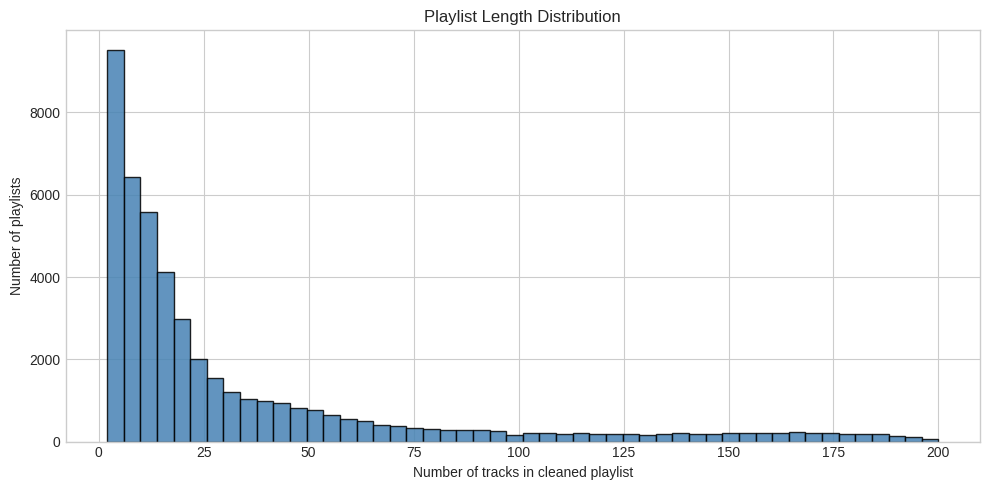

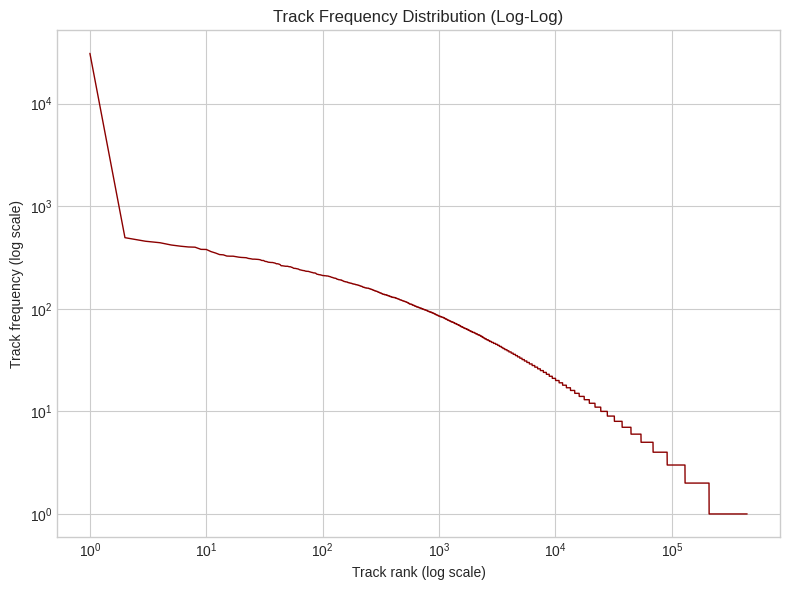

Saved figure: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/figures/playlist_length_histogram.png
Saved figure: /content/drive/MyDrive/CS455/HW1/artifacts/part_a/figures/track_frequency_loglog.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(playlist_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_title('Playlist Length Distribution')
ax.set_xlabel('Number of tracks in cleaned playlist')
ax.set_ylabel('Number of playlists')
fig.tight_layout()
playlist_hist_path = FIGURE_DIR / 'playlist_length_histogram.png'
fig.savefig(playlist_hist_path, dpi=200, bbox_inches='tight')
plt.show()

rank_values = np.arange(1, len(track_freq_df) + 1)
count_values = track_freq_df['count'].to_numpy()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rank_values, count_values, linewidth=1.0, color='darkred')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Track Frequency Distribution (Log-Log)')
ax.set_xlabel('Track rank (log scale)')
ax.set_ylabel('Track frequency (log scale)')
fig.tight_layout()
track_loglog_path = FIGURE_DIR / 'track_frequency_loglog.png'
fig.savefig(track_loglog_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved figure: {playlist_hist_path}')
print(f'Saved figure: {track_loglog_path}')

In [12]:
top_tracks_df = track_freq_df.head(20).copy()
top_tracks_df[['artist', 'title']] = top_tracks_df['token'].str.split('__', n=1, expand=True)
top_tracks_df = top_tracks_df[['artist', 'title', 'count', 'token']]

top_artists_df = artist_freq_df.head(20).copy()

top_tracks_df.to_csv(TABLE_DIR / 'top_20_tracks.csv', index=False)
top_artists_df.to_csv(TABLE_DIR / 'top_20_artists.csv', index=False)

print('Top 20 tracks')
display(top_tracks_df)

print('Top 20 artists')
display(top_artists_df)

print('Vocabulary statistics')
display(vocab_stats_df.style.format({'value': lambda x: f'{int(x):,}' if x == int(x) else f'{x:.2f}'}))

print('Coverage analysis')
display(coverage_df)

Top 20 tracks


,artist,title,count,token
0,zz_top,she_loves_my_automobile,30954,zz_top__she_loves_my_automobile
1,massive_attack,teardrop,494,massive_attack__teardrop
2,joy_division,love_will_tear_us_apart,456,joy_division__love_will_tear_us_apart
3,radiohead,karma_police,441,radiohead__karma_police
4,nirvana,smells_like_teen_spirit,419,nirvana__smells_like_teen_spirit
5,mgmt,kids,408,mgmt__kids
6,radiohead,creep,401,radiohead__creep
7,oasis,wonderwall,399,oasis__wonderwall
8,the_killers,mr._brightside,380,the_killers__mr._brightside
9,the_rolling_stones,paint_it_black,379,the_rolling_stones__paint_it_black


Top 20 artists


,artist,count
0,zz_top,31624
1,radiohead,7684
2,the_beatles,6506
3,coldplay,4555
4,pink_floyd,4468
5,depeche_mode,4276
6,muse,4273
7,the_rolling_stones,3965
8,metallica,3931
9,the_cure,3924


Vocabulary statistics


,metric,value
0,num_clean_playlists,"46,991"
1,total_track_events,"1,595,490"
2,unique_tracks,"443,306"
3,unique_artists,"60,103"
4,hapax_legomena,"234,775"
5,hapax_percentage,52.96
6,mean_playlist_length,33.95
7,median_playlist_length,15
8,max_playlist_length,200


Coverage analysis


,top_vocab_fraction,top_n_tracks,covered_event_share_pct
0,0.01,4434,21.795123
1,0.05,22166,42.472219
2,0.10,44331,54.266150


## Part B: Song2Vec Model Training

In [13]:
# Part B.1: Baseline Word2Vec Model
%pip install -q -U gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.6 MB/s eta 0:00:00


In [14]:
import os
import time
import gensim
import scipy
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

PART_B_DIR = PROJECT_DIR / 'artifacts' / 'part_b'
BASELINE_DIR = PART_B_DIR / 'baseline'
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Logical CPU count: {os.cpu_count()}')
print(f'Baseline artifacts will be saved under: {BASELINE_DIR}')

Logical CPU count: 2
Baseline artifacts will be saved under: /content/drive/MyDrive/CS455/HW1/artifacts/part_b/baseline


In [15]:
train_playlists = load_pickle(CACHE_DIR / 'train_playlists.pkl')
test_playlists = load_pickle(CACHE_DIR / 'test_playlists.pkl')

assert len(train_playlists) > 0, 'train_playlists.pkl is empty.'
assert len(test_playlists) > 0, 'test_playlists.pkl is empty.'

sample_token = train_playlists[0][0]
left_part, right_part = sample_token.split('__', 1)
assert ' ' not in left_part and ' ' not in right_part, (
    'Detected old space-based tokens. Rerun Part A from the helper cell onward to regenerate underscore-based tokens.'
)

baseline_data_df = pd.DataFrame(
    [
        {'split': 'train', 'num_playlists': len(train_playlists), 'num_track_events': sum(len(p) for p in train_playlists)},
        {'split': 'test', 'num_playlists': len(test_playlists), 'num_track_events': sum(len(p) for p in test_playlists)},
    ]
)

display(baseline_data_df)
print('Sample training playlist:')
print(train_playlists[0][:15])

,split,num_playlists,num_track_events
0,train,37592,1266295
1,test,9399,329195


Sample training playlist:
['the_whip__trash_(crookers_remix)', 'modeselektor__sucker_pin', 'simian_mobile_disco__hustler', 'gossip__standing_in_the_way_of_control', 'kalwi_&_remi__explosion_(dj_theo_remix)', 'jackson_and_his_computer_band__arpeggio', 'midnight_juggernauts__into_the_galaxy', "klaxons__it's_not_over_yet", 'yeah_yeah_yeahs__maps', 'radiohead__true_love_waits_(live)', 'queens_of_the_stone_age__make_it_wit_chu', 'queens_of_the_stone_age__feel_good_hit_of_the_summer', "beastie_boys__i_don't_know", 'the_rakes__the_world_was_a_mess_but_his_hair_was_perfect', 'foo_fighters__my_hero']


In [16]:
class EpochLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.records = []
        self.previous_loss = 0.0
        self.epoch_start_time = None

    def on_epoch_begin(self, model):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, model):
        cumulative_loss = float(model.get_latest_training_loss())
        epoch_loss = cumulative_loss - self.previous_loss if self.epoch > 0 else cumulative_loss
        elapsed_seconds = time.time() - self.epoch_start_time if self.epoch_start_time is not None else None
        self.records.append(
            {
                'epoch': self.epoch + 1,
                'cumulative_loss': cumulative_loss,
                'epoch_loss_delta': epoch_loss,
                'elapsed_seconds': elapsed_seconds,
            }
        )
        self.previous_loss = cumulative_loss
        self.epoch += 1


baseline_config = {
    'vector_size': 100,
    'window': 5,
    'min_count': 5,
    'sg': 1,
    'negative': 5,
    'ns_exponent': 0.75,
    'workers': min(4, os.cpu_count() or 1),
    'epochs': 5,
    'seed': RANDOM_SEED,
}

save_json(baseline_config, BASELINE_DIR / 'baseline_config.json')
display(pd.DataFrame({'parameter': list(baseline_config.keys()), 'value': list(baseline_config.values())}))

,parameter,value
0,vector_size,100.00
1,window,5.00
2,min_count,5.00
3,sg,1.00
4,negative,5.00
5,ns_exponent,0.75
6,workers,2.00
7,epochs,5.00
8,seed,455.00


In [17]:
epoch_logger = EpochLogger()
training_start_time = time.time()

baseline_model = Word2Vec(
    sentences=train_playlists,
    vector_size=baseline_config['vector_size'],
    window=baseline_config['window'],
    min_count=baseline_config['min_count'],
    sg=baseline_config['sg'],
    negative=baseline_config['negative'],
    ns_exponent=baseline_config['ns_exponent'],
    workers=baseline_config['workers'],
    epochs=baseline_config['epochs'],
    seed=baseline_config['seed'],
    compute_loss=True,
    callbacks=[epoch_logger],
)

training_seconds = time.time() - training_start_time

baseline_training_log_df = pd.DataFrame(epoch_logger.records)
baseline_training_log_df.to_csv(BASELINE_DIR / 'baseline_training_log.csv', index=False)

baseline_model_path = BASELINE_DIR / 'baseline_word2vec.model'
baseline_vectors_path = BASELINE_DIR / 'baseline_word_vectors.kv'
baseline_model.save(str(baseline_model_path))
baseline_model.wv.save(str(baseline_vectors_path))

baseline_summary = {
    'training_seconds': training_seconds,
    'vocabulary_size': len(baseline_model.wv),
    'corpus_count': baseline_model.corpus_count,
    'corpus_total_words': baseline_model.corpus_total_words,
    'model_path': str(baseline_model_path),
    'vectors_path': str(baseline_vectors_path),
}
save_json(baseline_summary, BASELINE_DIR / 'baseline_summary.json')

display(baseline_training_log_df)
display(pd.DataFrame({'metric': list(baseline_summary.keys()), 'value': list(baseline_summary.values())}))

,epoch,cumulative_loss,epoch_loss_delta,elapsed_seconds
0,1,7430937.0,7430937.0,20.372724
1,2,12210728.0,4779791.0,12.376232
2,3,15327716.0,3116988.0,14.591515
3,4,19009670.0,3681954.0,19.121889
4,5,22811108.0,3801438.0,16.553104


,metric,value
0,training_seconds,85.047945
1,vocabulary_size,53727
2,corpus_count,37592
3,corpus_total_words,1266295
4,model_path,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/baseline/baseline_word2vec.model
5,vectors_path,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/baseline/baseline_word_vectors.kv


In [18]:
#Baseline Model Training
train_track_counter = Counter(track for playlist in train_playlists for track in playlist)
seed_token = train_track_counter.most_common(1)[0][0]
most_similar_df = pd.DataFrame(
    baseline_model.wv.most_similar(seed_token, topn=10),
    columns=['similar_token', 'cosine_similarity'],
)

print(f'Seed token used for sanity check: {seed_token}')
display(most_similar_df)

Seed token used for sanity check: zz_top__she_loves_my_automobile


,similar_token,cosine_similarity
0,john_williams__the_imperial_march_(darth_vader's_theme),0.497193
1,max_romeo__i_chase_the_devil,0.490893
2,bing_crosby__white_christmas,0.486789
3,philip_glass__mad_rush,0.485074
4,byetone__grand_style,0.483213
5,nat_king_cole__the_christmas_song,0.482495
6,john_coltrane__giant_steps,0.482413
7,philip_glass__metamorphosis_five,0.481453
8,tommy_castro__a_good_fool_is_hard_to_find,0.481340
9,alva_noto__pulse_(xs_version),0.479726


In [19]:
#B.2 Hyperparameter Experiments
HYPERPARAMETER_SPACE = {
    'sg'         : [0, 1],
    'window'     : [5, 20, 40],
    'negative'   : [5, 10, 15],
    'ns_exponent': [0.75, -1.0, -0.5, 0.0, 0.5, 1.0],
    'min_count'  : [3, 5, 10],
    'vector_size': [50, 100, 300],
    'epochs'     : [5, 20, 50],
}

# K_playlist: how many of the LAST K songs of each playlist to use for training.
# None = full playlist (baseline). This is a data-preprocessing hyperparameter,
# not a Word2Vec parameter, so it is handled separately below.

K_PLAYLIST_SPACE    = [25, 50, 100, 150]
K_PLAYLIST_BASELINE = None    # None means "use full playlist"

SWEEP_DIR = PART_B_DIR / 'hyperparameter_experiments'
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

def format_value_for_name(value):
    value_str = str(value).replace('-', 'neg_').replace('.', '_')
    value_str = re.sub(r'__+', '_', value_str)
    return value_str.strip('_')


#Build experiment registry
experiment_registry = [
    {
        'experiment_name' : 'baseline_reference',
        'varied_parameter': 'baseline',
        'varied_value'    : 'baseline',
        'config'          : baseline_config.copy(),
        'K_playlist'      : K_PLAYLIST_BASELINE,
    }
]

#One-factor-at-a-time Word2Vec hyperparameters
for parameter_name, values in HYPERPARAMETER_SPACE.items():
    baseline_value = baseline_config[parameter_name]
    for value in values:
        if value == baseline_value:
            continue
        experiment_config = baseline_config.copy()
        experiment_config[parameter_name] = value
        experiment_registry.append({
            'experiment_name' : f'{parameter_name}_{format_value_for_name(value)}',
            'varied_parameter': parameter_name,
            'varied_value'    : value,
            'config'          : experiment_config,
            'K_playlist'      : K_PLAYLIST_BASELINE,   #full playlist for all W2V experiments
        })

#K_playlist experiments (keep all other hyperparameters at baseline)
for K_p in K_PLAYLIST_SPACE:
    experiment_registry.append({
        'experiment_name' : f'k_playlist_{K_p}',
        'varied_parameter': 'K_playlist',
        'varied_value'    : K_p,
        'config'          : baseline_config.copy(),
        'K_playlist'      : K_p,
    })

experiment_plan_df = pd.DataFrame([
    {
        'experiment_name' : item['experiment_name'],
        'varied_parameter': item['varied_parameter'],
        'varied_value'    : item['varied_value'],
        'K_playlist'      : item['K_playlist'],
        **item['config'],
    }
    for item in experiment_registry
])

save_json(
    [{
        'experiment_name' : item['experiment_name'],
        'varied_parameter': item['varied_parameter'],
        'varied_value'    : item['varied_value'],
        'K_playlist'      : item['K_playlist'],
        'config'          : item['config'],
    } for item in experiment_registry],
    SWEEP_DIR / 'experiment_registry.json',
)

display(experiment_plan_df)
print(f'Total experiments in sweep: {len(experiment_registry)}  ')
print(f'Experiment registry saved to: {SWEEP_DIR / "experiment_registry.json"}')

,experiment_name,varied_parameter,varied_value,K_playlist,vector_size,window,min_count,sg,negative,ns_exponent,workers,epochs,seed
0,baseline_reference,baseline,baseline,NaN,100,5,5,1,5,0.75,2,5,455
1,sg_0,sg,0,NaN,100,5,5,0,5,0.75,2,5,455
2,window_20,window,20,NaN,100,20,5,1,5,0.75,2,5,455
3,window_40,window,40,NaN,100,40,5,1,5,0.75,2,5,455
4,negative_10,negative,10,NaN,100,5,5,1,10,0.75,2,5,455
5,negative_15,negative,15,NaN,100,5,5,1,15,0.75,2,5,455
6,ns_exponent_neg_1_0,ns_exponent,-1.0,NaN,100,5,5,1,5,-1.00,2,5,455
7,ns_exponent_neg_0_5,ns_exponent,-0.5,NaN,100,5,5,1,5,-0.50,2,5,455
8,ns_exponent_0_0,ns_exponent,0.0,NaN,100,5,5,1,5,0.00,2,5,455
9,ns_exponent_0_5,ns_exponent,0.5,NaN,100,5,5,1,5,0.50,2,5,455


Total experiments in sweep: 21  
Experiment registry saved to: /content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/experiment_registry.json


In [20]:
def train_word2vec_experiment(experiment_name, config, sentences, varied_parameter,
                               varied_value, K_playlist=None,
                               overwrite=False, save_full_model=False):
    """
    Train one Word2Vec experiment and cache results.

    K_playlist: if not None, each playlist is truncated to its last K_playlist
    songs before training.
    """
    experiment_dir = SWEEP_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    summary_path  = experiment_dir / 'summary.json'
    log_path      = experiment_dir / 'training_log.csv'
    vectors_path  = experiment_dir / 'word_vectors.kv'
    model_path    = experiment_dir / 'word2vec.model'
    config_path   = experiment_dir / 'config.json'

    if summary_path.exists() and log_path.exists() and vectors_path.exists() and not overwrite:
        cached = pd.read_json(summary_path, typ='series').to_dict()
        cached['loaded_from_cache'] = True
        return cached

    #Apply K_playlist truncation
    if K_playlist is not None:
        sentences = [pl[-K_playlist:] for pl in sentences]
        sentences = [pl for pl in sentences if len(pl) >= 2]

    save_json(config, config_path)
    logger     = EpochLogger()
    start_time = time.time()

    model = Word2Vec(
        sentences   = sentences,
        vector_size = config['vector_size'],
        window      = config['window'],
        min_count   = config['min_count'],
        sg          = config['sg'],
        negative    = config['negative'],
        ns_exponent = config['ns_exponent'],
        workers     = config['workers'],
        epochs      = config['epochs'],
        seed        = config['seed'],
        compute_loss= True,
        callbacks   = [logger],
    )

    training_seconds   = time.time() - start_time
    training_log_df    = pd.DataFrame(logger.records)
    training_log_df.to_csv(log_path, index=False)
    model.wv.save(str(vectors_path))
    if save_full_model:
        model.save(str(model_path))

    summary = {
        'experiment_name'      : experiment_name,
        'varied_parameter'     : varied_parameter,
        'varied_value'         : varied_value,
        'K_playlist'           : K_playlist,          #stored so eval can apply same truncation
        'training_seconds'     : float(training_seconds),
        'vocabulary_size'      : int(len(model.wv)),
        'corpus_count'         : int(model.corpus_count),
        'corpus_total_words'   : int(model.corpus_total_words),
        'final_cumulative_loss': float(training_log_df['cumulative_loss'].iloc[-1])
                                 if not training_log_df.empty else None,
        'final_epoch_loss_delta': float(training_log_df['epoch_loss_delta'].iloc[-1])
                                  if not training_log_df.empty else None,
        'vectors_path'         : str(vectors_path),
        'model_path'           : str(model_path) if save_full_model else None,
        'loaded_from_cache'    : False,
    }

    save_json(summary, summary_path)
    return summary

In [21]:
OVERWRITE_EXISTING_EXPERIMENTS = False
SAVE_FULL_MODELS_FOR_SWEEP     = False

experiment_results = []
for experiment_number, experiment_item in enumerate(experiment_registry, start=1):
    experiment_name   = experiment_item['experiment_name']
    varied_parameter  = experiment_item['varied_parameter']
    varied_value      = experiment_item['varied_value']
    K_playlist        = experiment_item.get('K_playlist', None)

    print(f'[{experiment_number:>2}/{len(experiment_registry)}] {experiment_name} '
          f'(K_playlist={K_playlist}) ...')

    summary = train_word2vec_experiment(
        experiment_name  = experiment_name,
        config           = experiment_item['config'],
        sentences        = train_playlists,
        varied_parameter = varied_parameter,
        varied_value     = varied_value,
        K_playlist       = K_playlist,
        overwrite        = OVERWRITE_EXISTING_EXPERIMENTS,
        save_full_model  = SAVE_FULL_MODELS_FOR_SWEEP,
    )
    experiment_results.append(summary)

experiment_results_df = pd.DataFrame(experiment_results)
experiment_results_df['training_minutes'] = experiment_results_df['training_seconds'] / 60.0
experiment_results_df = experiment_results_df.sort_values(
    ['varied_parameter', 'experiment_name']).reset_index(drop=True)
experiment_results_df.to_csv(SWEEP_DIR / 'experiment_results_summary.csv', index=False)

display(experiment_results_df)
print(f'Saved sweep summary to: {SWEEP_DIR / "experiment_results_summary.csv"}')

[ 1/21] baseline_reference (K_playlist=None) ...
[ 2/21] sg_0 (K_playlist=None) ...
[ 3/21] window_20 (K_playlist=None) ...
[ 4/21] window_40 (K_playlist=None) ...
[ 5/21] negative_10 (K_playlist=None) ...
[ 6/21] negative_15 (K_playlist=None) ...
[ 7/21] ns_exponent_neg_1_0 (K_playlist=None) ...
[ 8/21] ns_exponent_neg_0_5 (K_playlist=None) ...
[ 9/21] ns_exponent_0_0 (K_playlist=None) ...
[10/21] ns_exponent_0_5 (K_playlist=None) ...
[11/21] ns_exponent_1_0 (K_playlist=None) ...
[12/21] min_count_3 (K_playlist=None) ...
[13/21] min_count_10 (K_playlist=None) ...
[14/21] vector_size_50 (K_playlist=None) ...
[15/21] vector_size_300 (K_playlist=None) ...
[16/21] epochs_20 (K_playlist=None) ...
[17/21] epochs_50 (K_playlist=None) ...
[18/21] k_playlist_25 (K_playlist=25) ...
[19/21] k_playlist_50 (K_playlist=50) ...
[20/21] k_playlist_100 (K_playlist=100) ...
[21/21] k_playlist_150 (K_playlist=150) ...


,experiment_name,varied_parameter,varied_value,training_seconds,vocabulary_size,corpus_count,corpus_total_words,final_cumulative_loss,final_epoch_loss_delta,vectors_path,model_path,loaded_from_cache,K_playlist,training_minutes
0,k_playlist_100,K_playlist,100,26.607997,45294,37592,1088644,17683488.0,2738980.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/k_playlist_100/word_vectors.kv,None,True,100.0,0.443467
1,k_playlist_150,K_playlist,150,32.232405,51934,37592,1226032,21161232.0,3488754.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/k_playlist_150/word_vectors.kv,None,True,150.0,0.537207
2,k_playlist_25,K_playlist,25,9.545019,21107,37592,573954,8723836.0,1135091.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/k_playlist_25/word_vectors.kv,None,True,25.0,0.159084
3,k_playlist_50,K_playlist,50,20.034310,32836,37592,825942,12650702.0,1654804.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/k_playlist_50/word_vectors.kv,None,True,50.0,0.333905
4,baseline_reference,baseline,baseline,46.286684,53727,37592,1266295,22344084.0,3658482.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/baseline_reference/word_vectors.kv,None,True,NaN,0.771445
5,epochs_20,epochs,20,142.125538,53727,37592,1266295,41642076.0,781196.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/epochs_20/word_vectors.kv,None,True,NaN,2.368759
6,epochs_50,epochs,50,345.451401,53727,37592,1266295,54665460.0,450660.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/epochs_50/word_vectors.kv,None,True,NaN,5.757523
7,min_count_10,min_count,10,21.000675,20990,37592,1266295,15004867.0,2271206.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/min_count_10/word_vectors.kv,None,True,NaN,0.350011
8,min_count_3,min_count,3,48.335175,104924,37592,1266295,30497160.0,4586136.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/min_count_3/word_vectors.kv,None,True,NaN,0.805586
9,negative_10,negative,10,68.135085,53727,37592,1266295,25600080.0,3788018.0,/content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/negative_10/word_vectors.kv,None,True,NaN,1.135585


Saved sweep summary to: /content/drive/MyDrive/CS455/HW1/artifacts/part_b/hyperparameter_experiments/experiment_results_summary.csv


In [22]:
display_columns = [
    'experiment_name',
    'varied_parameter',
    'varied_value',
    'vocabulary_size',
    'training_seconds',
    'training_minutes',
    'final_epoch_loss_delta',
    'loaded_from_cache',
]

for parameter_name in ['baseline', 'sg', 'window', 'negative', 'ns_exponent', 'min_count', 'vector_size', 'epochs']:
    subset_df = experiment_results_df.loc[
        experiment_results_df['varied_parameter'] == parameter_name,
        display_columns,
    ]
    if not subset_df.empty:
        print(f'\nResults for {parameter_name}')
        display(subset_df)


Results for baseline


,experiment_name,varied_parameter,varied_value,vocabulary_size,training_seconds,training_minutes,final_epoch_loss_delta,loaded_from_cache
4,baseline_reference,baseline,baseline,53727,46.286684,0.771445,3658482.0,True



Results for sg


,experiment_name,varied_parameter,varied_value,vocabulary_size,training_seconds,training_minutes,final_epoch_loss_delta,loaded_from_cache
16,sg_0,sg,0,53727,15.087013,0.25145,1171894.0,True



Results for window


...

,experiment_name,varied_parameter,varied_value,vocabulary_size,training_seconds,training_minutes,final_epoch_loss_delta,loaded_from_cache
7,min_count_10,min_count,10,20990,21.000675,0.350011,2271206.0,True
8,min_count_3,min_count,3,104924,48.335175,0.805586,4586136.0,True



Results for vector_size


,experiment_name,varied_parameter,varied_value,vocabulary_size,training_seconds,training_minutes,final_epoch_loss_delta,loaded_from_cache
17,vector_size_300,vector_size,300,53727,57.78846,0.963141,3793548.0,True
18,vector_size_50,vector_size,50,53727,40.60754,0.676792,3623162.0,True



Results for epochs


,experiment_name,varied_parameter,varied_value,vocabulary_size,training_seconds,training_minutes,final_epoch_loss_delta,loaded_from_cache
5,epochs_20,epochs,20,53727,142.125538,2.368759,781196.0,True
6,epochs_50,epochs,50,53727,345.451401,5.757523,450660.0,True


In [23]:
#B.3: K_playlist experiments
#Train with playlists truncated to last K songs.
#Baseline hyperparameters are held fixed; only K_playlist varies.
#Results appended to experiment_results_df BEFORE the evaluation loop.

K_PLAYLIST_VALUES    = [25, 50, 100, 150]
K_PLAYLIST_TRAIN_DIR = PART_B_DIR / 'k_playlist_experiments'
K_PLAYLIST_TRAIN_DIR.mkdir(parents=True, exist_ok=True)
OVERWRITE_K_PLAYLIST = False

k_playlist_rows = []

for K_p in K_PLAYLIST_VALUES:
    exp_name = f'k_playlist_{K_p}'
    exp_dir  = K_PLAYLIST_TRAIN_DIR / exp_name
    exp_dir.mkdir(parents=True, exist_ok=True)
    vpath    = exp_dir / 'word_vectors.kv'
    sj_path  = exp_dir / 'summary.json'

    if sj_path.exists() and vpath.exists() and not OVERWRITE_K_PLAYLIST:
        with open(sj_path) as f:
            summary = json.load(f)
        summary['loaded_from_cache'] = True
        k_playlist_rows.append(summary)
        print(f'[CACHE] {exp_name}  vocab={summary["vocabulary_size"]}')
        continue

    trunc_train = [pl[-K_p:] for pl in train_playlists if len(pl[-K_p:]) >= 2]
    cfg    = baseline_config.copy()
    logger = EpochLogger()
    t0     = time.time()
    model  = Word2Vec(
        sentences=trunc_train,
        vector_size=cfg['vector_size'], window=cfg['window'],
        min_count=cfg['min_count'],     sg=cfg['sg'],
        negative=cfg['negative'],       ns_exponent=cfg['ns_exponent'],
        workers=cfg['workers'],         epochs=cfg['epochs'],
        seed=cfg['seed'],               compute_loss=True,
        callbacks=[logger])
    tr_sec = time.time() - t0
    model.wv.save(str(vpath))
    pd.DataFrame(logger.records).to_csv(exp_dir / 'training_log.csv', index=False)
    summary = {
        'experiment_name'  : exp_name,
        'varied_parameter' : 'K_playlist',
        'varied_value'     : str(K_p),
        'K_playlist'       : K_p,
        'vocabulary_size'  : len(model.wv),
        'training_seconds' : round(tr_sec, 2),
        'vectors_path'     : str(vpath),
        'loaded_from_cache': False,
    }
    save_json(summary, sj_path)
    k_playlist_rows.append(summary)
    print(f'[DONE] {exp_name}  vocab={len(model.wv)}  n_train={len(trunc_train)}  time={tr_sec:.1f}s')

k_playlist_df         = pd.DataFrame(k_playlist_rows)
experiment_results_df = pd.concat([experiment_results_df, k_playlist_df], ignore_index=True)
print(f'experiment_results_df: {len(experiment_results_df)} rows '
      f'({len(k_playlist_rows)} K_playlist + {len(experiment_results_df)-len(k_playlist_rows)} sweep)')
display(k_playlist_df[['experiment_name', 'K_playlist', 'vocabulary_size', 'training_seconds']])

[CACHE] k_playlist_25  vocab=21107
[CACHE] k_playlist_50  vocab=32836
[CACHE] k_playlist_100  vocab=45294
[CACHE] k_playlist_150  vocab=51934
experiment_results_df: 25 rows (4 K_playlist + 21 sweep)


,experiment_name,K_playlist,vocabulary_size,training_seconds
0,k_playlist_25,25,21107,8.24
1,k_playlist_50,50,32836,17.14
2,k_playlist_100,100,45294,28.50
3,k_playlist_150,150,51934,33.48


## Part C: Evaluation

In [24]:
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from gensim.models import KeyedVectors

#Directories
PART_C_DIR = PROJECT_DIR / 'artifacts' / 'part_c'
EVAL_RESULTS_DIR = PART_C_DIR / 'evaluation_results'
PART_C_DIR.mkdir(parents=True, exist_ok=True)
EVAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_K_VALUES = [5, 10, 20, 50]

#Reload cached data
test_playlists  = load_pickle(CACHE_DIR / 'test_playlists.pkl')
train_playlists = load_pickle(CACHE_DIR / 'train_playlists.pkl')
test_records    = load_pickle(CACHE_DIR / 'test_playlist_records.pkl')

experiment_results_df = pd.read_csv(SWEEP_DIR / 'experiment_results_summary.csv')

#Reload EDA tables
artist_freq_df = pd.read_csv(TABLE_DIR / 'eda_artist_frequency.csv')
track_freq_df  = pd.read_csv(TABLE_DIR / 'eda_track_frequency.csv')

print(f'Test playlists : {len(test_playlists)}')
print(f'Train playlists: {len(train_playlists)}')
print(f'Experiments    : {len(experiment_results_df)}')
display(experiment_results_df[['experiment_name', 'varied_parameter', 'varied_value', 'vocabulary_size']])

Test playlists : 9399
Train playlists: 37592
Experiments    : 21


,experiment_name,varied_parameter,varied_value,vocabulary_size
0,k_playlist_100,K_playlist,100,45294
1,k_playlist_150,K_playlist,150,51934
2,k_playlist_25,K_playlist,25,21107
3,k_playlist_50,K_playlist,50,32836
4,baseline_reference,baseline,baseline,53727
5,epochs_20,epochs,20,53727
6,epochs_50,epochs,50,53727
7,min_count_10,min_count,10,20990
8,min_count_3,min_count,3,104924
9,negative_10,negative,10,53727


In [25]:
#Batch evaluation helpers
#Uses matrix operations (vocab_size × d matmul) instead of per-sample calls,
#to reduce evaluation time.

def _normed(wv):
    """Return L2-normalised copy of the word-vector matrix (float32)."""
    V = wv.vectors.astype(np.float32)
    norms = np.linalg.norm(V, axis=1, keepdims=True)
    np.clip(norms, 1e-8, None, out=norms)
    return V / norms


def _prepare_test_cases(wv, playlists, K_playlist=None):
    """
    Convert playlists to evaluation cases.
    Each case records context indices, query index, and target index.
    Returns (cases, skip_counter).
    """
    w2i = {w: i for i, w in enumerate(wv.index_to_key)}
    vocab = set(wv.index_to_key)
    cases, skipped = [], Counter()

    for pl in playlists:
        if K_playlist is not None and len(pl) > K_playlist:
            pl = pl[-K_playlist:]
        if len(pl) < 2:
            skipped['too_short'] += 1
            continue
        context, target = pl[:-1], pl[-1]
        if target not in vocab:
            skipped['oov_target'] += 1
            continue
        query = context[-1]
        known_ctx_idx = [w2i[s] for s in context if s in vocab]
        cases.append({
            'target_idx'    : w2i[target],
            'query_idx'     : w2i[query] if query in vocab else None,
            'query_in_vocab': query in vocab,
            'ctx_indices'   : known_ctx_idx,
            'has_context'   : len(known_ctx_idx) > 0,
        })
    return cases, skipped


def _batch_approach2(V_norm, cases, K_values, chunk=800):
    """Paper Approach: (n-1)th song → top-K."""
    max_K   = max(K_values)
    valid   = [c for c in cases if c['query_in_vocab']]
    n_oov_q = len(cases) - len(valid)
    if not valid:
        return {**{f'hr@{k}': 0.0 for k in K_values},
                **{f'ndcg@{k}': 0.0 for k in K_values},
                'n_evaluated': 0, 'n_oov_query': n_oov_q}

    hr   = {k: np.zeros(len(valid), np.float32) for k in K_values}
    ndcg = {k: np.zeros(len(valid), np.float32) for k in K_values}

    for s in range(0, len(valid), chunk):
        batch  = valid[s:s + chunk]
        q_idx  = np.array([c['query_idx']  for c in batch])
        t_idx  = np.array([c['target_idx'] for c in batch])
        sims   = V_norm[q_idx] @ V_norm.T          #(B, vocab)
        #exclude query from its own ranking
        sims[np.arange(len(batch)), q_idx] = -np.inf

        for j in range(len(batch)):
            top = np.argpartition(sims[j], -max_K)[-max_K:]
            top = top[np.argsort(sims[j, top])[::-1]]
            for k in K_values:
                hits = np.where(top[:k] == t_idx[j])[0]
                if len(hits):
                    rank = hits[0] + 1
                    hr[k][s + j]   = 1.0
                    ndcg[k][s + j] = 1.0 / np.log2(rank + 1)

    n = len(valid)
    return {**{f'hr@{k}':   float(hr[k].mean())   * 100 for k in K_values},
            **{f'ndcg@{k}': float(ndcg[k].mean())       for k in K_values},
            'n_evaluated': n, 'n_oov_query': n_oov_q}


def _batch_approach1(V_norm, cases, K_values, chunk=800):
    """Context Averaging: mean of N-1 known song vectors → top-K."""
    max_K     = max(K_values)
    valid     = [c for c in cases if c['has_context']]
    n_no_ctx  = len(cases) - len(valid)
    if not valid:
        return {**{f'hr@{k}': 0.0 for k in K_values},
                **{f'ndcg@{k}': 0.0 for k in K_values},
                'n_evaluated': 0, 'n_no_context': n_no_ctx}

    hr   = {k: np.zeros(len(valid), np.float32) for k in K_values}
    ndcg = {k: np.zeros(len(valid), np.float32) for k in K_values}

    #Pre-compute normalised average context vectors
    avg_vecs = np.zeros((len(valid), V_norm.shape[1]), np.float32)
    ctx_sets = []
    for i, c in enumerate(valid):
        v    = V_norm[c['ctx_indices']].mean(axis=0)
        norm = np.linalg.norm(v)
        avg_vecs[i] = v / norm if norm > 1e-8 else v
        ctx_sets.append(set(c['ctx_indices']))

    for s in range(0, len(valid), chunk):
        batch  = valid[s:s + chunk]
        A      = avg_vecs[s:s + chunk]
        t_idx  = np.array([c['target_idx'] for c in batch])
        sims   = A @ V_norm.T                       #(B, vocab)
        #exclude context songs per row
        for j, ctx_set in enumerate(ctx_sets[s:s + chunk]):
            if ctx_set:
                sims[j, list(ctx_set)] = -np.inf

        for j in range(len(batch)):
            top = np.argpartition(sims[j], -max_K)[-max_K:]
            top = top[np.argsort(sims[j, top])[::-1]]
            for k in K_values:
                hits = np.where(top[:k] == t_idx[j])[0]
                if len(hits):
                    rank = hits[0] + 1
                    hr[k][s + j]   = 1.0
                    ndcg[k][s + j] = 1.0 / np.log2(rank + 1)

    n = len(valid)
    return {**{f'hr@{k}':   float(hr[k].mean())   * 100 for k in K_values},
            **{f'ndcg@{k}': float(ndcg[k].mean())       for k in K_values},
            'n_evaluated': n, 'n_no_context': n_no_ctx}


def evaluate_model(vectors_path, test_playlists, K_values, K_playlist=None,
                   cache_path=None):
    """
    Load saved KeyedVectors, evaluate both approaches.
    Results are JSON-cached to avoid re-running.
    """
    if cache_path and Path(cache_path).exists():
        with open(cache_path) as f:
            r = json.load(f)
        r['from_cache'] = True
        return r

    wv     = KeyedVectors.load(str(vectors_path))
    V_norm = _normed(wv)
    cases, skipped = _prepare_test_cases(wv, test_playlists, K_playlist)

    t0  = time.time()
    a1  = _batch_approach1(V_norm, cases, K_values)
    a2  = _batch_approach2(V_norm, cases, K_values)
    out = {'approach1': a1, 'approach2': a2,
           'n_skipped': dict(skipped), 'eval_sec': time.time() - t0,
           'from_cache': False}

    if cache_path:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        with open(cache_path, 'w') as f:
            json.dump(out, f, indent=2)
    return out

In [26]:
#Evaluate every experiment from the Part B sweep
#K_playlist experiments automatically apply the correct truncation at eval time.
#(same K used during training is used during evaluation)

OVERWRITE_EVAL = False   # set True to force re-evaluation

all_eval_rows = []

for _, row in experiment_results_df.iterrows():
    exp_name   = row['experiment_name']
    vec_path   = row['vectors_path']
    varied_par = row['varied_parameter']
    varied_val = row['varied_value']

    #K_playlist stored in summary; NaN → None (full playlist)
    K_playlist_val = None
    raw_kp = row.get('K_playlist', None)
    if raw_kp is not None and not (isinstance(raw_kp, float) and np.isnan(raw_kp)):
        K_playlist_val = int(raw_kp)

    if pd.isna(vec_path) or not Path(vec_path).exists():
        print(f'  [SKIP – no vectors] {exp_name}')
        continue

    cache_path = EVAL_RESULTS_DIR / f'{exp_name}.json'
    if OVERWRITE_EVAL and cache_path.exists():
        cache_path.unlink()

    res = evaluate_model(
        vectors_path   = vec_path,
        test_playlists = test_playlists,
        K_values       = EVAL_K_VALUES,
        K_playlist     = K_playlist_val,
        cache_path     = cache_path,
    )

    a1, a2 = res['approach1'], res['approach2']
    tag    = '(cached)' if res['from_cache'] else f'({res["eval_sec"]:.1f}s)'
    kp_str = f' K_pl={K_playlist_val}' if K_playlist_val else ''
    print(f'  {exp_name:<35}{kp_str:<10} {tag:>10}  |  '
          f'A2 HR@10={a2.get("hr@10",0):.2f}%  HR@50={a2.get("hr@50",0):.2f}%')

    all_eval_rows.append({
        'experiment_name' : exp_name,
        'varied_parameter': varied_par,
        'varied_value'    : varied_val,
        'K_playlist'      : K_playlist_val,
        **{f'a1_{k}': v for k, v in a1.items()},
        **{f'a2_{k}': v for k, v in a2.items()},
    })

eval_df = pd.DataFrame(all_eval_rows)
eval_df.to_csv(EVAL_RESULTS_DIR / 'all_experiments_eval.csv', index=False)
print(f'\nSaved -> {EVAL_RESULTS_DIR / "all_experiments_eval.csv"}')
display(eval_df[['experiment_name','varied_parameter','varied_value','K_playlist',
                  'a2_hr@5','a2_hr@10','a2_hr@20','a2_hr@50',
                  'a1_hr@10','a2_ndcg@10']].sort_values('a2_hr@10', ascending=False))

  k_playlist_100                      K_pl=100    (cached)  |  A2 HR@10=3.01%  HR@50=5.45%
  k_playlist_150                      K_pl=150    (cached)  |  A2 HR@10=3.20%  HR@50=6.08%
  k_playlist_25                       K_pl=25     (cached)  |  A2 HR@10=2.11%  HR@50=3.87%
  k_playlist_50                       K_pl=50     (cached)  |  A2 HR@10=2.01%  HR@50=4.93%
  baseline_reference                              (cached)  |  A2 HR@10=3.56%  HR@50=6.49%
  epochs_20                                       (cached)  |  A2 HR@10=5.41%  HR@50=11.82%
  epochs_50                                       (cached)  |  A2 HR@10=5.30%  HR@50=11.20%
  min_count_10                                    (cached)  |  A2 HR@10=6.53%  HR@50=12.15%
  min_count_3                                     (cached)  |  A2 HR@10=2.33%  HR@50=4.45%
  negative_10                                     (cached)  |  A2 HR@10=3.73%  HR@50=7.53%
  negative_15                                     (cached)  |  A2 HR@10=4.19%  HR@50=8.

,experiment_name,varied_parameter,varied_value,K_playlist,a2_hr@5,a2_hr@10,a2_hr@20,a2_hr@50,a1_hr@10,a2_ndcg@10
7,min_count_10,min_count,10,NaN,4.469914,6.532951,8.424069,12.148997,2.759949,0.036098
5,epochs_20,epochs,20,NaN,3.662365,5.406348,8.092082,11.824206,3.092075,0.030422
6,epochs_50,epochs,50,NaN,3.557726,5.301709,7.429369,11.196373,2.633990,0.029913
20,window_40,window,40,NaN,3.627485,5.301709,7.359609,11.126613,2.611086,0.030560
19,window_20,window,20,NaN,3.034531,4.638996,7.115452,11.021974,2.863033,0.025243
10,negative_15,negative,15,NaN,2.929892,4.185560,5.999302,8.754796,1.763628,0.023568
13,ns_exponent_1_0,ns_exponent,1.0,NaN,2.790373,3.836763,5.476107,8.022323,1.855245,0.020818
9,negative_10,negative,10,NaN,2.720614,3.732124,5.476107,7.534008,1.672011,0.021028
18,vector_size_50,vector_size,50,NaN,2.302058,3.627485,4.883153,6.627136,1.488777,0.019568
4,baseline_reference,baseline,baseline,NaN,2.302058,3.557726,4.778514,6.487618,1.374256,0.019411


In [27]:
#Per-hyperparameter result tables
metric_cols = ['a2_hr@5','a2_hr@10','a2_hr@20','a2_hr@50',
               'a2_ndcg@10','a1_hr@10','a1_ndcg@10']

for param in ['baseline','sg','window','negative','ns_exponent',
              'min_count','vector_size','epochs','K_playlist']:
    subset = eval_df[eval_df['varied_parameter'] == param].copy()
    if subset.empty:
        continue
    subset = subset.sort_values('a2_hr@10', ascending=False)
    print(f'\n── {param} ──')
    display(subset[['experiment_name','varied_value'] + metric_cols].reset_index(drop=True))

#Find best value per hyperparameter
#For each param, pick the value that achieved the highest A2 HR@10.
#Use that value only if it beats (or ties) baseline; otherwise keep default.

PARAM_TO_CFG_KEY = {
    'sg'         : ('sg',          int),
    'window'     : ('window',      int),
    'negative'   : ('negative',    int),
    'ns_exponent': ('ns_exponent', float),
    'min_count'  : ('min_count',   int),
    'vector_size': ('vector_size', int),
    'epochs'     : ('epochs',      int),
}

baseline_hr10 = eval_df[eval_df['experiment_name'] == 'baseline_reference']['a2_hr@10'].values[0]

best_config   = baseline_config.copy()
best_K_playlist = None   #None = no truncation
summary_rows  = []

for param, (cfg_key, cast) in PARAM_TO_CFG_KEY.items():
    subset = eval_df[eval_df['varied_parameter'] == param]
    if subset.empty:
        summary_rows.append({'param': param, 'best_value': best_config[cfg_key],
                             'a2_hr@10': baseline_hr10, 'note': 'not swept'})
        continue
    top = subset.sort_values('a2_hr@10', ascending=False).iloc[0]
    if top['a2_hr@10'] >= baseline_hr10:
        val = cast(top['varied_value'])
        best_config[cfg_key] = val
        note = 'swept winner'
    else:
        val  = best_config[cfg_key]
        note = 'baseline wins'
    summary_rows.append({'param': param, 'best_value': val,
                         'a2_hr@10': top['a2_hr@10'], 'note': note})

#for K_playlist
kp_sub = eval_df[eval_df['varied_parameter'] == 'K_playlist']
if not kp_sub.empty:
    top_kp = kp_sub.sort_values('a2_hr@10', ascending=False).iloc[0]
    if top_kp['a2_hr@10'] >= baseline_hr10:
        best_K_playlist = int(top_kp['K_playlist'])
        note_kp = 'swept winner'
    else:
        note_kp = 'baseline wins (no truncation)'
    summary_rows.append({'param': 'K_playlist', 'best_value': best_K_playlist,
                         'a2_hr@10': top_kp['a2_hr@10'], 'note': note_kp})

print('\n══ Best value per hyperparameter ══')
display(pd.DataFrame(summary_rows).set_index('param'))
print(f'\nBest combined config : {best_config}')
print(f'Best K_playlist      : {best_K_playlist}')

#Train the best combined model
BEST_MODEL_DIR = PART_B_DIR / 'best_combined_model'
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_vpath  = BEST_MODEL_DIR / 'word_vectors.kv'
best_sj     = BEST_MODEL_DIR / 'summary.json'
OVERWRITE_BEST = False

best_exp_name = 'best_combined'

if best_sj.exists() and best_vpath.exists() and not OVERWRITE_BEST:
    print('\n[CACHE] best_combined model loaded from disk.')
else:
    train_data = train_playlists
    if best_K_playlist is not None:
        train_data = [pl[-best_K_playlist:] for pl in train_playlists
                      if len(pl[-best_K_playlist:]) >= 2]
    logger = EpochLogger()
    t0 = time.time()
    best_model = Word2Vec(
        sentences=train_data,
        vector_size=best_config['vector_size'], window=best_config['window'],
        min_count=best_config['min_count'],     sg=best_config['sg'],
        negative=best_config['negative'],       ns_exponent=best_config['ns_exponent'],
        workers=best_config['workers'],         epochs=best_config['epochs'],
        seed=best_config['seed'],               compute_loss=True,
        callbacks=[logger])
    tr_sec = time.time() - t0
    best_model.wv.save(str(best_vpath))
    pd.DataFrame(logger.records).to_csv(BEST_MODEL_DIR / 'training_log.csv', index=False)
    save_json({'experiment_name': best_exp_name,
               'config': {k: v for k, v in best_config.items() if k != 'workers'},
               'K_playlist': best_K_playlist,
               'vocabulary_size': len(best_model.wv),
               'training_seconds': round(tr_sec, 2),
               'vectors_path': str(best_vpath)}, best_sj)
    print(f'\n[DONE] best_combined  vocab={len(best_model.wv)}  '
          f'n_train={len(train_data)}  time={tr_sec:.1f}s')

#Evaluate best combined model
best_vec_path = best_vpath
best_cache    = EVAL_RESULTS_DIR / f'{best_exp_name}.json'
if OVERWRITE_BEST and best_cache.exists():
    best_cache.unlink()

best_eval = evaluate_model(
    vectors_path   = best_vec_path,
    test_playlists = test_playlists,
    K_values       = EVAL_K_VALUES,
    K_playlist     = best_K_playlist,
    cache_path     = best_cache,
)
a1b, a2b = best_eval['approach1'], best_eval['approach2']
print(f'\n★ Best Combined Model Evaluation')
print(f'   A2 HR@5={a2b.get("hr@5",0):.2f}%  HR@10={a2b.get("hr@10",0):.2f}%  '
      f'HR@20={a2b.get("hr@20",0):.2f}%  HR@50={a2b.get("hr@50",0):.2f}%')
print(f'   A2 NDCG@10={a2b.get("ndcg@10",0):.4f}')
print(f'   A1 HR@10={a1b.get("hr@10",0):.2f}%  NDCG@10={a1b.get("ndcg@10",0):.4f}')
print(f'   Baseline A2 HR@10={baseline_hr10:.2f}%  '
      f'Δ={a2b.get("hr@10",0)-baseline_hr10:+.2f}%')


── baseline ──


,experiment_name,varied_value,a2_hr@5,a2_hr@10,a2_hr@20,a2_hr@50,a2_ndcg@10,a1_hr@10,a1_ndcg@10
0,baseline_reference,baseline,2.302058,3.557726,4.778514,6.487618,0.019411,1.374256,0.008106



── sg ──


,experiment_name,varied_value,a2_hr@5,a2_hr@10,a2_hr@20,a2_hr@50,a2_ndcg@10,a1_hr@10,a1_ndcg@10
0,sg_0,0,0.627834,0.767353,1.290548,1.953261,0.0048,0.526798,0.003081



── window ──


...


── K_playlist ──


,experiment_name,varied_value,a2_hr@5,a2_hr@10,a2_hr@20,a2_hr@50,a2_ndcg@10,a1_hr@10,a1_ndcg@10
0,k_playlist_150,150,2.025586,3.198294,4.406539,6.076759,0.017733,1.273738,0.006822
1,k_playlist_100,100,2.096037,3.010671,4.153964,5.449695,0.018026,1.448576,0.006865
2,k_playlist_25,25,1.407625,2.111437,2.697947,3.870968,0.011167,1.168452,0.005767
3,k_playlist_50,50,1.459854,2.007299,3.284672,4.927007,0.010663,1.280305,0.006317



══ Best value per hyperparameter ══


,best_value,a2_hr@10,note
param,,,
sg,1.0,0.767353,baseline wins
window,40.0,5.301709,swept winner
negative,15.0,4.185560,swept winner
ns_exponent,1.0,3.836763,swept winner
min_count,10.0,6.532951,swept winner
vector_size,50.0,3.627485,swept winner
epochs,20.0,5.406348,swept winner
K_playlist,NaN,3.198294,baseline wins (no truncation)



Best combined config : {'vector_size': 50, 'window': 40, 'min_count': 10, 'sg': 1, 'negative': 15, 'ns_exponent': 1.0, 'workers': 2, 'epochs': 20, 'seed': 455}
Best K_playlist      : None

[CACHE] best_combined model loaded from disk.

★ Best Combined Model Evaluation
   A2 HR@5=7.74%  HR@10=12.32%  HR@20=16.50%  HR@50=22.92%
   A2 NDCG@10=0.0677
   A1 HR@10=8.34%  NDCG@10=0.0509
   Baseline A2 HR@10=3.56%  Δ=+8.76%


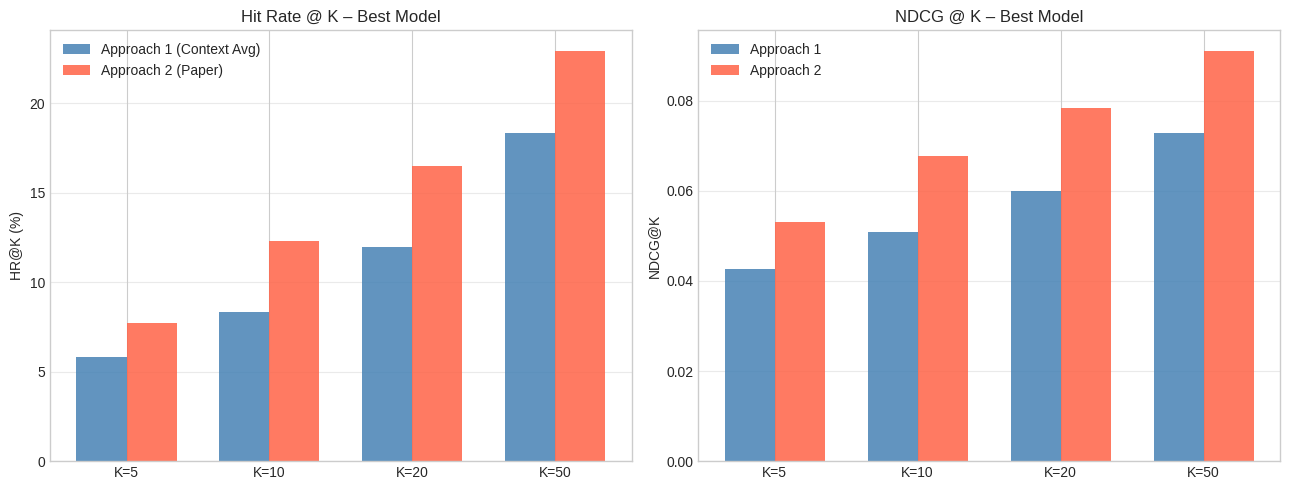

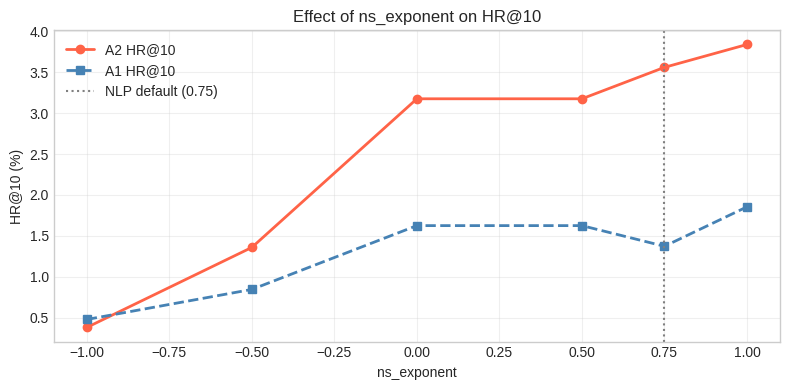

In [29]:
#C.1 Next-Song Prediction Task
#HR@K comparison: Approach 1 vs Approach 2
k_labels = [5, 10, 20, 50]
a1b, a2b = best_eval['approach1'], best_eval['approach2']

best_row = pd.Series({
    **{f'a1_hr@{k}':   a1b.get(f'hr@{k}',   0) for k in k_labels},
    **{f'a1_ndcg@{k}': a1b.get(f'ndcg@{k}', 0) for k in k_labels},
    **{f'a2_hr@{k}':   a2b.get(f'hr@{k}',   0) for k in k_labels},
    **{f'a2_ndcg@{k}': a2b.get(f'ndcg@{k}', 0) for k in k_labels},
})

a1_hr = [best_row[f'a1_hr@{k}'] for k in k_labels]
a2_hr = [best_row[f'a2_hr@{k}'] for k in k_labels]

x = np.arange(len(k_labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#HR@K
ax = axes[0]
ax.bar(x - w/2, a1_hr, w, label='Approach 1 (Context Avg)', color='steelblue', alpha=0.85)
ax.bar(x + w/2, a2_hr, w, label='Approach 2 (Paper)',       color='tomato',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in k_labels])
ax.set_ylabel('HR@K (%)'); ax.set_title('Hit Rate @ K – Best Model')
ax.legend(); ax.grid(axis='y', alpha=0.4)

#NDCG@K
a1_ndcg = [best_row[f'a1_ndcg@{k}'] for k in k_labels]
a2_ndcg = [best_row[f'a2_ndcg@{k}'] for k in k_labels]
ax = axes[1]
ax.bar(x - w/2, a1_ndcg, w, label='Approach 1', color='steelblue', alpha=0.85)
ax.bar(x + w/2, a2_ndcg, w, label='Approach 2', color='tomato',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in k_labels])
ax.set_ylabel('NDCG@K'); ax.set_title('NDCG @ K – Best Model')
ax.legend(); ax.grid(axis='y', alpha=0.4)

fig.tight_layout()
fig.savefig(PART_C_DIR / 'approach_comparison_best.png', dpi=180, bbox_inches='tight')
plt.show()

#ns_exponent sweep chart
ns_df = eval_df[eval_df['varied_parameter'].isin(['ns_exponent','baseline'])].copy()
ns_df['ns_val'] = ns_df.apply(
    lambda r: 0.75 if r['varied_parameter'] == 'baseline' else float(r['varied_value']), axis=1)
ns_df = ns_df.sort_values('ns_val')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns_df['ns_val'], ns_df['a2_hr@10'], 'o-', color='tomato',    label='A2 HR@10', lw=2)
ax.plot(ns_df['ns_val'], ns_df['a1_hr@10'], 's--', color='steelblue', label='A1 HR@10', lw=2)
ax.axvline(0.75, color='grey', ls=':', label='NLP default (0.75)')
ax.set_xlabel('ns_exponent'); ax.set_ylabel('HR@10 (%)')
ax.set_title('Effect of ns_exponent on HR@10')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(PART_C_DIR / 'ns_exponent_hr10.png', dpi=180, bbox_inches='tight')
plt.show()

In [30]:
#C.2 Qualitative Analysis
#Load best model and baseline vectors
best_wv      = KeyedVectors.load(str(best_vec_path))
baseline_wv  = KeyedVectors.load(
    str(SWEEP_DIR / 'baseline_reference' / 'word_vectors.kv'))

#most_similar for seed songs
seed_songs = [
    'queen__bohemian_rhapsody',
    'led_zeppelin__stairway_to_heaven',
    'radiohead__creep',
    'nirvana__smells_like_teen_spirit',
    'the_beatles__come_together',
    'pink_floyd__comfortably_numb',
    'green_day__basket_case',
]

qual_rows = []
print(f'Using model: {best_exp_name}\n')
for seed in seed_songs:
    if seed not in best_wv:
        print(f'[OOV] {seed}\n')
        continue
    print(f'▶  {seed}')
    similar = best_wv.most_similar(seed, topn=10)
    for rank, (song, score) in enumerate(similar, 1):
        print(f'   {rank:2}. {song:<60} {score:.4f}')
        qual_rows.append({'seed': seed, 'rank': rank, 'similar_song': song, 'score': score})
    print()

qual_df = pd.DataFrame(qual_rows)
qual_df.to_csv(PART_C_DIR / 'qualitative_most_similar.csv', index=False)
print(f'Saved → {PART_C_DIR / "qualitative_most_similar.csv"}')

Using model: best_combined

▶  queen__bohemian_rhapsody
    1. queen__we_will_rock_you                                      0.8795
    2. queen__another_one_bites_the_dust                            0.8753
    3. queen__we_are_the_champions                                  0.8615
    4. queen__don't_stop_me_now                                     0.8525
    5. queen__i_want_it_all                                         0.8404
    6. queen__bicycle_race                                          0.8370
    7. queen__killer_queen                                          0.8310
    8. queen__the_show_must_go_on                                   0.8195
    9. queen__i_want_to_break_free                                  0.8191
   10. queen__somebody_to_love                                      0.8038

▶  led_zeppelin__stairway_to_heaven
    1. led_zeppelin__whole_lotta_love                               0.8847
    2. led_zeppelin__immigrant_song                                 0.8607
    3. 

In [31]:
#Song algebra
algebra_queries = [
    {
        'desc'    : 'radiohead__creep - radiohead__karma_police + oasis__wonderwall',
        'positive': ['radiohead__creep', 'oasis__wonderwall'],
        'negative': ['radiohead__karma_police'],
    },
    {
        'desc'    : 'nirvana__come_as_you_are - nirvana__smells_like_teen_spirit + metallica__one',
        'positive': ['nirvana__come_as_you_are', 'metallica__one'],
        'negative': ['nirvana__smells_like_teen_spirit'],
    },
    {
        'desc'    : 'led_zeppelin__stairway_to_heaven - led_zeppelin__whole_lotta_love + pink_floyd__wish_you_were_here',
        'positive': ['led_zeppelin__stairway_to_heaven', 'pink_floyd__wish_you_were_here'],
        'negative': ['led_zeppelin__whole_lotta_love'],
    },
    {
        'desc'    : 'the_beatles__let_it_be - the_beatles__hey_jude + the_rolling_stones__gimme_shelter',
        'positive': ['the_beatles__let_it_be', 'the_rolling_stones__gimme_shelter'],
        'negative': ['the_beatles__hey_jude'],
    },
    {
        'desc'    : 'green_day__basket_case - green_day__when_i_come_around + blink-182__all_the_small_things',
        'positive': ['green_day__basket_case', 'blink-182__all_the_small_things'],
        'negative': ['green_day__when_i_come_around'],
    },
]

algebra_rows = []
print('=== Song Algebra (best model) ===\n')
for q in algebra_queries:
    pos_ok = [s for s in q['positive'] if s in best_wv]
    neg_ok = [s for s in q['negative'] if s in best_wv]
    print(f'Query: {q["desc"]}')
    if not pos_ok:
        print('  [all positive terms OOV]\n')
        continue
    try:
        results = best_wv.most_similar(positive=pos_ok, negative=neg_ok, topn=5)
        for rank, (song, score) in enumerate(results, 1):
            print(f'  {rank}. {song:<60} {score:.4f}')
            algebra_rows.append({'query': q['desc'], 'rank': rank,
                                  'result_song': song, 'score': score})
    except Exception as e:
        print(f'  Error: {e}')
    print()

pd.DataFrame(algebra_rows).to_csv(PART_C_DIR / 'song_algebra.csv', index=False)
print(f'Saved → {PART_C_DIR / "song_algebra.csv"}')

=== Song Algebra (best model) ===

Query: radiohead__creep - radiohead__karma_police + oasis__wonderwall
  1. oasis__don't_look_back_in_anger                              0.8206
  2. oasis__champagne_supernova                                   0.8038
  3. oasis__she's_electric                                        0.8031
  4. oasis__stop_crying_your_heart_out                            0.7916
  5. goo_goo_dolls__iris                                          0.7850

Query: nirvana__come_as_you_are - nirvana__smells_like_teen_spirit + metallica__one
  1. metallica__master_of_puppets                                 0.8894
  2. metallica__fade_to_black                                     0.8878
  3. metallica__sad_but_true                                      0.8846
  4. metallica__enter_sandman                                     0.8805
  5. metallica__battery                                           0.8792

Query: led_zeppelin__stairway_to_heaven - led_zeppelin__whole_lotta_love + pink

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


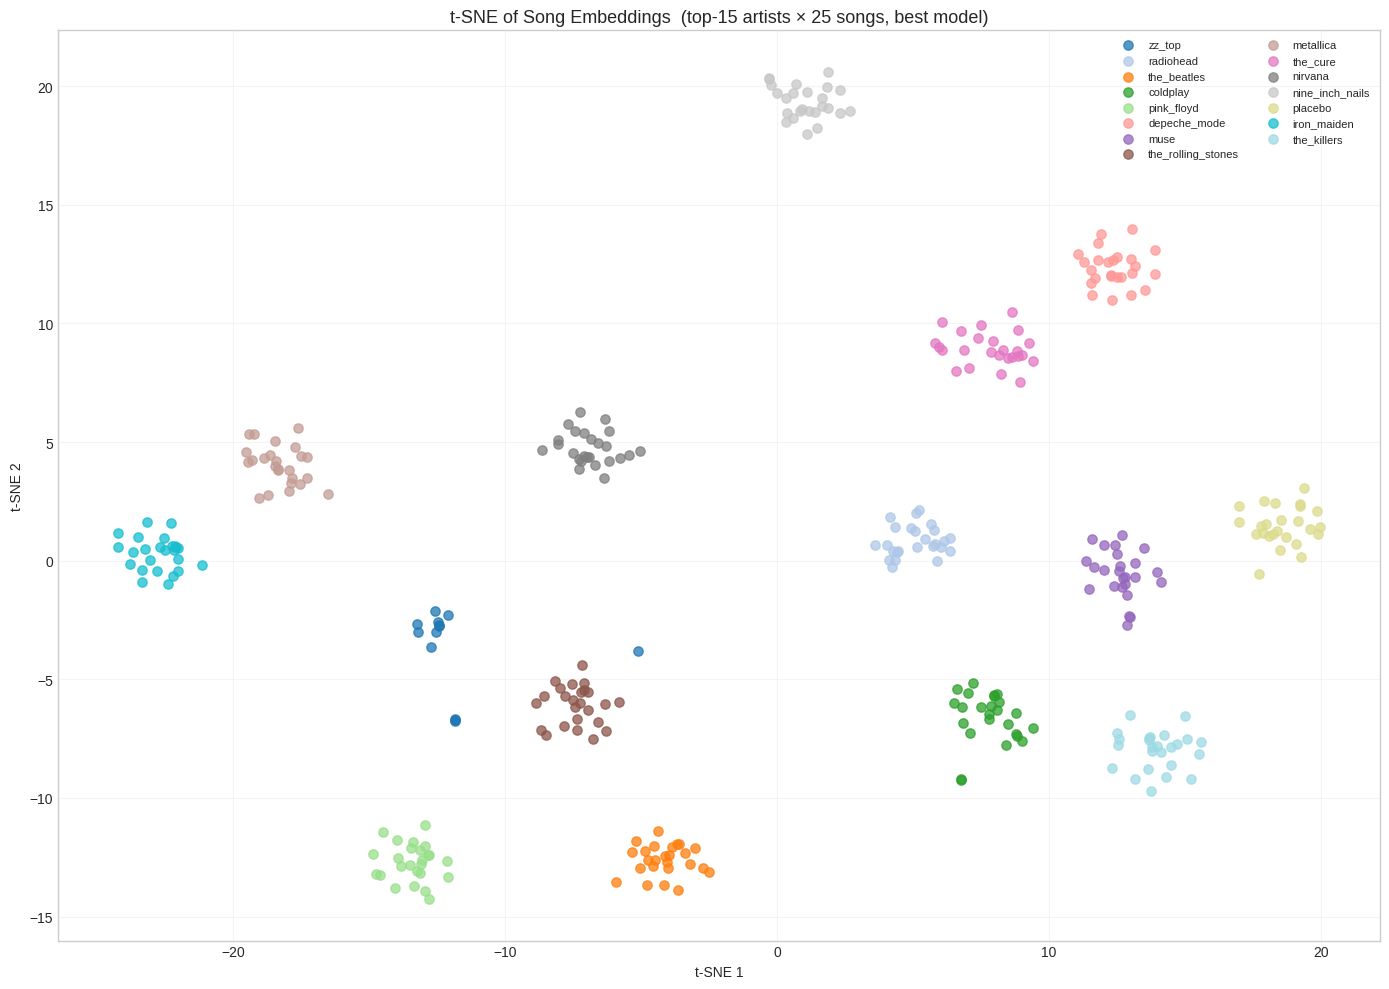

Saved → /content/drive/MyDrive/CS455/HW1/artifacts/part_c/tsne_embeddings.png


In [32]:
#t-SNE visualisation
from sklearn.manifold import TSNE

#Take top-15 artists and up to 25 of their most frequent songs
train_counter = Counter(t for pl in train_playlists for t in pl)

TOP_ARTISTS   = 15
SONGS_PER_ART = 25

top_artists = artist_freq_df.head(TOP_ARTISTS)['artist'].tolist()

tokens_plot, artist_labels, color_ids = [], [], []
for aid, artist in enumerate(top_artists):
    prefix    = artist + '__'
    art_songs = [t for t in best_wv.key_to_index if t.startswith(prefix)]
    art_songs = sorted(art_songs, key=lambda t: train_counter.get(t, 0), reverse=True)
    art_songs = art_songs[:SONGS_PER_ART]
    for s in art_songs:
        tokens_plot.append(s)
        artist_labels.append(artist)
        color_ids.append(aid)

vecs = np.array([best_wv[s] for s in tokens_plot], dtype=np.float32)

tsne  = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED,
             n_iter=1000, init='pca', learning_rate='auto')
xy    = tsne.fit_transform(vecs)

cmap  = plt.cm.tab20(np.linspace(0, 1, TOP_ARTISTS))
fig, ax = plt.subplots(figsize=(14, 10))
handles = []
for aid, artist in enumerate(top_artists):
    mask = np.array(color_ids) == aid
    sc   = ax.scatter(xy[mask, 0], xy[mask, 1],
                      color=cmap[aid], alpha=0.75, s=45, label=artist)
    handles.append(sc)

ax.legend(handles=handles, labels=top_artists,
          loc='upper right', fontsize=8, ncol=2, framealpha=0.8)
ax.set_title(f't-SNE of Song Embeddings  '
             f'(top-{TOP_ARTISTS} artists × {SONGS_PER_ART} songs, best model)',
             fontsize=13)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.grid(alpha=0.2)
fig.tight_layout()
tsne_path = PART_C_DIR / 'tsne_embeddings.png'
fig.savefig(tsne_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {tsne_path}')

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


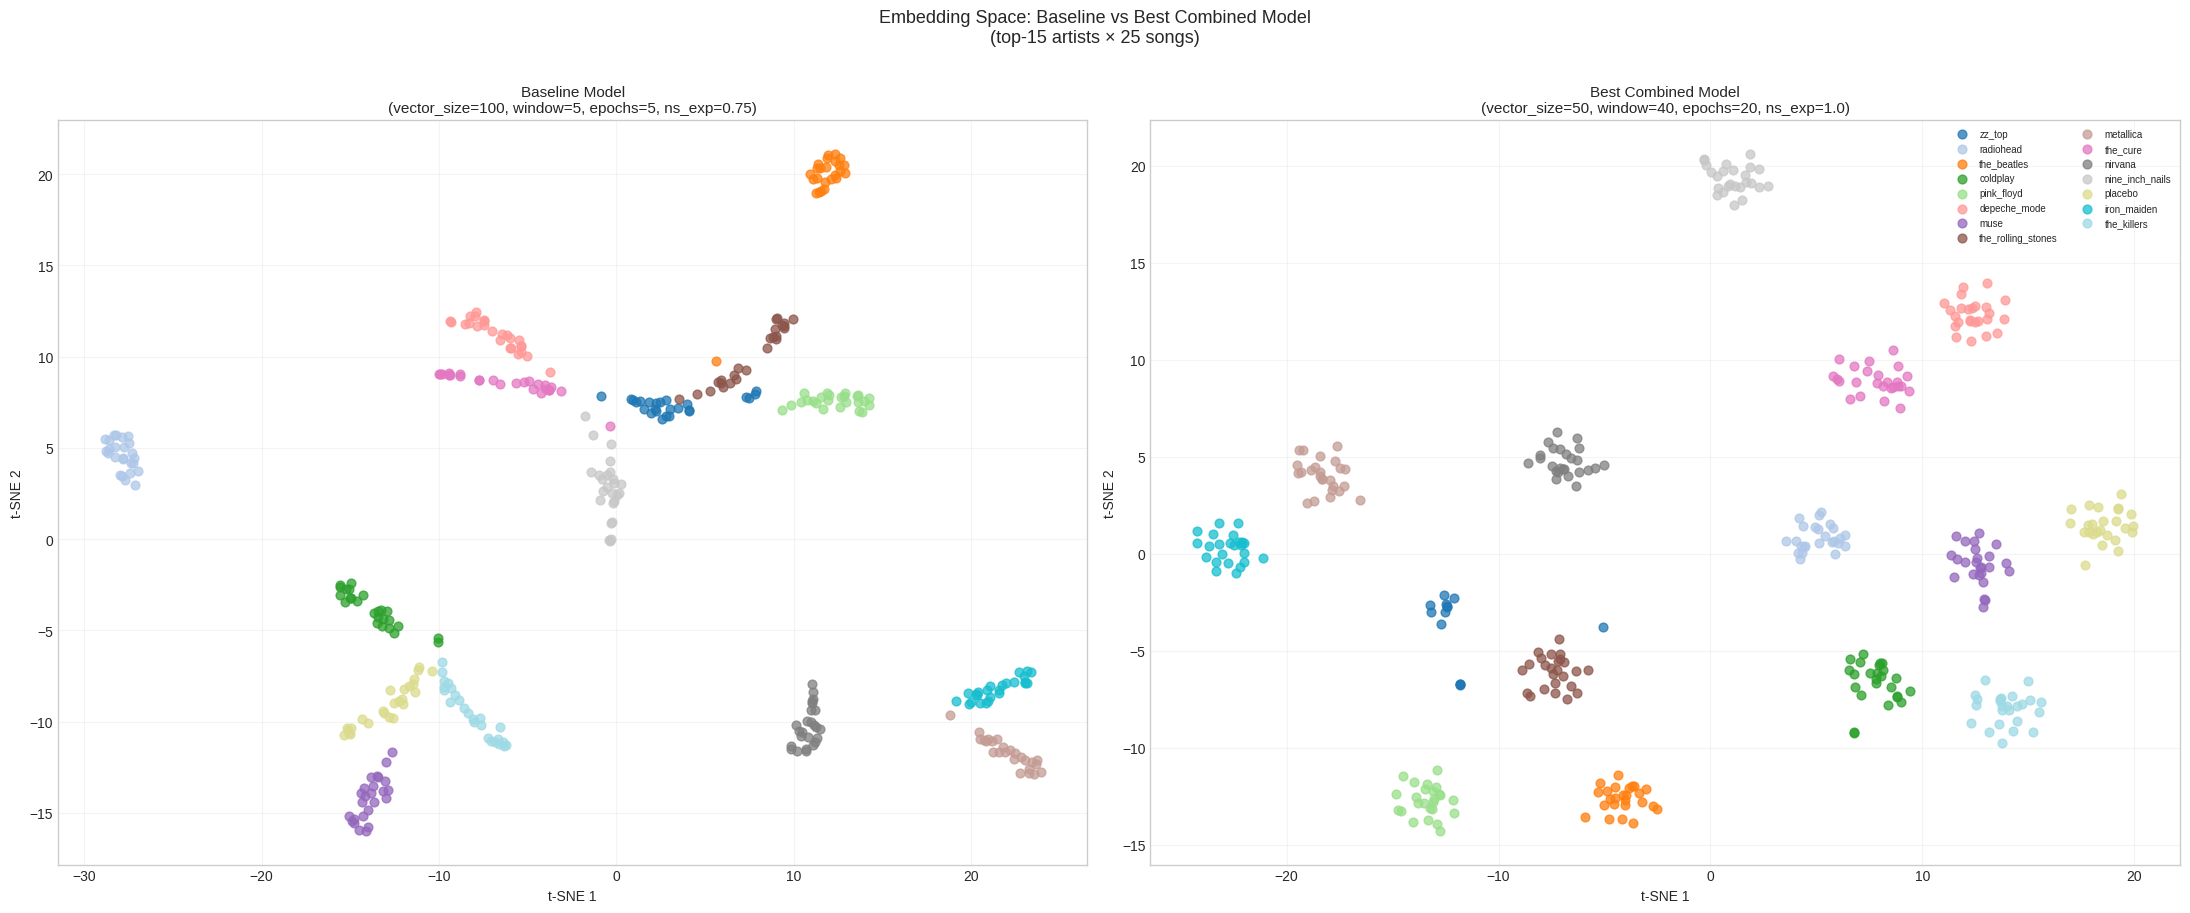

Saved → /content/drive/MyDrive/CS455/HW1/artifacts/part_c/tsne_baseline_vs_best.png


In [33]:
#Viz 1: Baseline vs Best Model side-by-side t-SNE
#Same artists and songs in both panels — shows how tuning reshaped the space.

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
cmap = plt.cm.tab20(np.linspace(0, 1, TOP_ARTISTS))

for ax, (wv, title) in zip(axes, [
        (baseline_wv, 'Baseline Model\n(vector_size=100, window=5, epochs=5, ns_exp=0.75)'),
        (best_wv,     f'Best Combined Model\n(vector_size={best_config["vector_size"]}, '
                      f'window={best_config["window"]}, epochs={best_config["epochs"]}, '
                      f'ns_exp={best_config["ns_exponent"]})'),
]):
    t_plot, a_ids = [], []
    for aid, artist in enumerate(top_artists):
        prefix    = artist + '__'
        art_songs = [t for t in wv.key_to_index if t.startswith(prefix)]
        art_songs = sorted(art_songs, key=lambda t: train_counter.get(t, 0), reverse=True)
        for s in art_songs[:SONGS_PER_ART]:
            t_plot.append(s)
            a_ids.append(aid)

    vecs_m = np.array([wv[s] for s in t_plot], dtype=np.float32)
    xy_m   = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED,
                  n_iter=1000, init='pca', learning_rate='auto').fit_transform(vecs_m)

    for aid, artist in enumerate(top_artists):
        mask = np.array(a_ids) == aid
        ax.scatter(xy_m[mask, 0], xy_m[mask, 1],
                   color=cmap[aid], alpha=0.75, s=40, label=artist)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(alpha=0.2)

axes[1].legend(top_artists, loc='upper right', fontsize=7, ncol=2, framealpha=0.8)
fig.suptitle(f'Embedding Space: Baseline vs Best Combined Model\n'
             f'(top-{TOP_ARTISTS} artists × {SONGS_PER_ART} songs)',
             fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(PART_C_DIR / 'tsne_baseline_vs_best.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved → {PART_C_DIR / "tsne_baseline_vs_best.png"}')

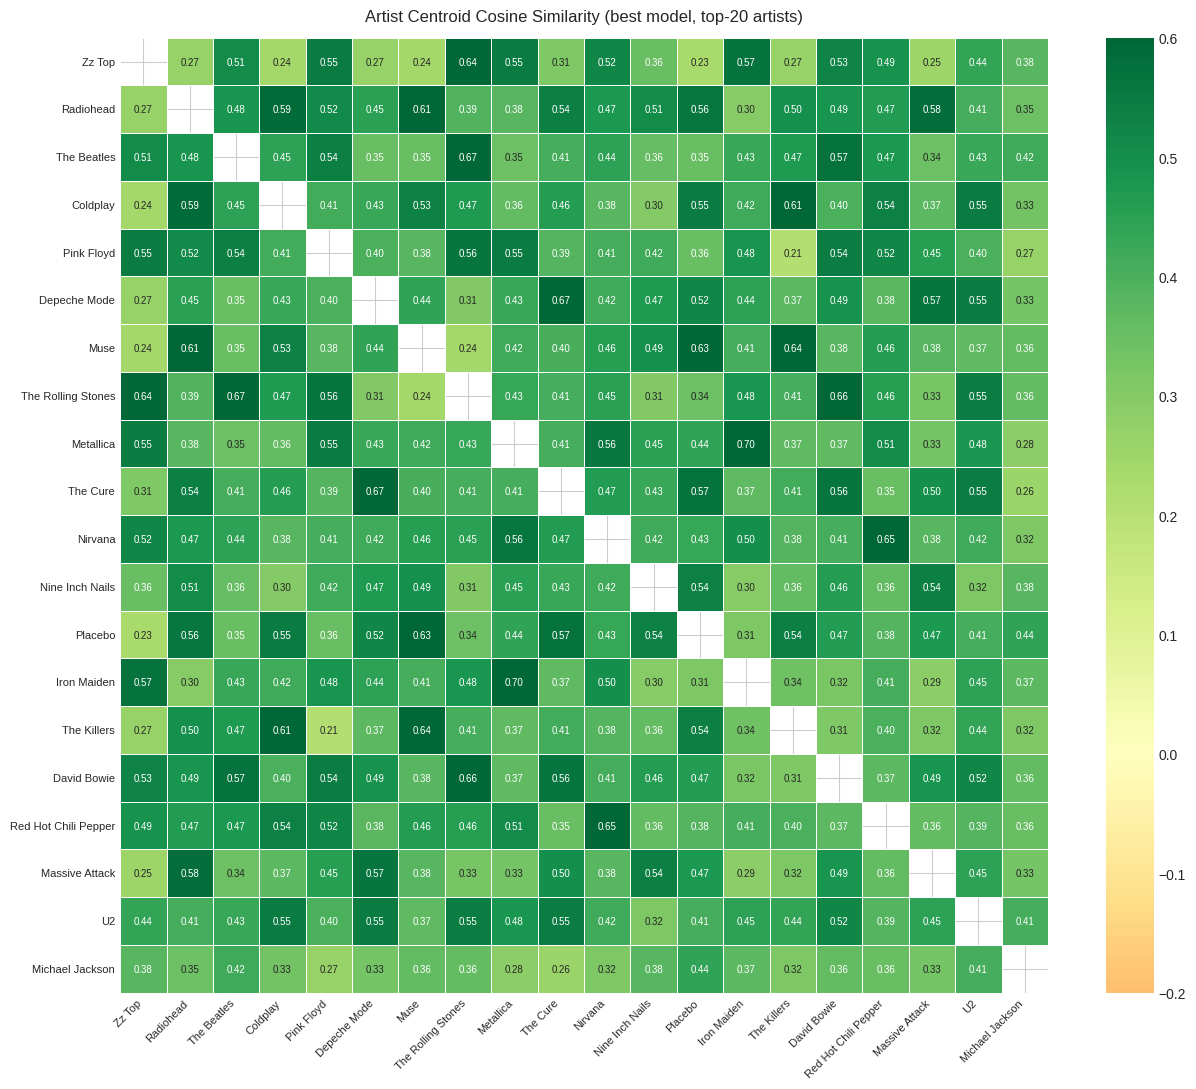

Saved → /content/drive/MyDrive/CS455/HW1/artifacts/part_c/artist_centroid_heatmap.png


In [34]:
#Viz 2: Artist-centroid cosine similarity heatmap
#Mean embedding per artist → pairwise cosine similarity matrix.
#Reveals which artists the model considers musically similar.

import seaborn as sns

TOP_HEATMAP = 20   #number of artists to include

heatmap_artists = artist_freq_df.head(TOP_HEATMAP)['artist'].tolist()
#Filter to artists with at least one song in best_wv
heatmap_artists = [
    a for a in heatmap_artists
    if any(t.startswith(a + '__') for t in best_wv.key_to_index)
]

#Compute mean (L2-normalised) centroid per artist
centroids, centroid_labels = [], []
for artist in heatmap_artists:
    prefix = artist + '__'
    songs  = [t for t in best_wv.key_to_index if t.startswith(prefix)]
    if not songs:
        continue
    vmat = np.array([best_wv[s] for s in songs], dtype=np.float32)
    cent = vmat.mean(axis=0)
    cent /= (np.linalg.norm(cent) + 1e-8)
    centroids.append(cent)
    #Shorten label for readability
    centroid_labels.append(artist.replace('_', ' ').title()[:20])

C = np.array(centroids, dtype=np.float32)          #(n_artists, d)
sim_matrix = C @ C.T                               #cosine similarity (already L2-normed)
np.fill_diagonal(sim_matrix, np.nan)               #mask self-similarity

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.eye(len(centroid_labels), dtype=bool)
sns.heatmap(
    sim_matrix,
    xticklabels=centroid_labels, yticklabels=centroid_labels,
    cmap='RdYlGn', center=0, vmin=-0.2, vmax=0.6,
    linewidths=0.4, linecolor='white',
    annot=True, fmt='.2f', annot_kws={'size': 7},
    mask=mask, ax=ax,
)
ax.set_title(f'Artist Centroid Cosine Similarity (best model, top-{len(centroid_labels)} artists)',
             fontsize=12, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
fig.tight_layout()
fig.savefig(PART_C_DIR / 'artist_centroid_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved → {PART_C_DIR / "artist_centroid_heatmap.png"}')

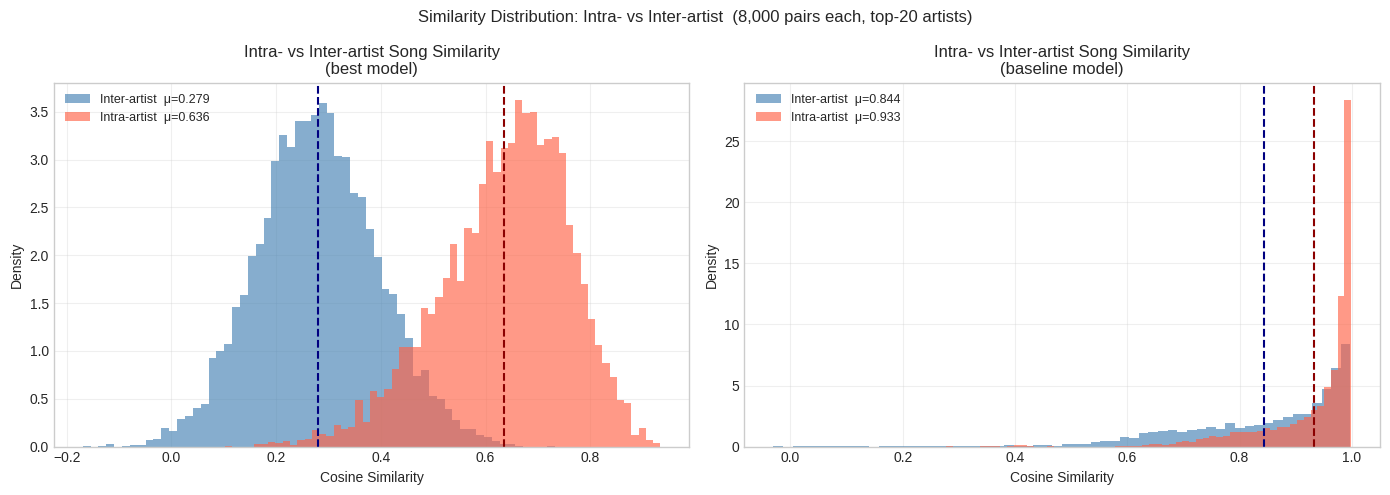

Intra−Inter gap  →  best=0.3566   baseline=0.0890
Saved → /content/drive/MyDrive/CS455/HW1/artifacts/part_c/similarity_distribution.png


In [35]:
#Viz 3: Intra- vs Inter-artist cosine similarity distribution
#Samples pairs of songs; compares within-artist similarity to across-artist.

RNG           = np.random.default_rng(RANDOM_SEED)
N_PAIRS       = 8_000   # pairs per category
SAMPLE_ARTISTS = 20     # artists to draw songs from

sample_artists = artist_freq_df.head(SAMPLE_ARTISTS)['artist'].tolist()

#Build per-artist song-index lists (only songs in best_wv)
artist_song_idx = {}
w2i = {w: i for i, w in enumerate(best_wv.index_to_key)}
V   = best_wv.vectors.astype(np.float32)
norms = np.linalg.norm(V, axis=1, keepdims=True)
V_norm = V / np.clip(norms, 1e-8, None)

for artist in sample_artists:
    prefix = artist + '__'
    idxs   = [w2i[t] for t in best_wv.index_to_key if t.startswith(prefix)]
    if len(idxs) >= 2:
        artist_song_idx[artist] = np.array(idxs)

artists_with_songs = list(artist_song_idx.keys())

#Intra-artist pairs: both songs from the same artist
intra_sims = []
for _ in range(N_PAIRS):
    art = RNG.choice(artists_with_songs)
    i, j = RNG.choice(artist_song_idx[art], size=2, replace=False)
    intra_sims.append(float(V_norm[i] @ V_norm[j]))

#Inter-artist pairs: songs from two different artists
inter_sims = []
for _ in range(N_PAIRS):
    a1, a2 = RNG.choice(artists_with_songs, size=2, replace=False)
    i = RNG.choice(artist_song_idx[a1])
    j = RNG.choice(artist_song_idx[a2])
    inter_sims.append(float(V_norm[i] @ V_norm[j]))

intra_sims = np.array(intra_sims)
inter_sims = np.array(inter_sims)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Histogram
ax = axes[0]
ax.hist(inter_sims, bins=60, alpha=0.65, color='steelblue', label=f'Inter-artist  μ={inter_sims.mean():.3f}', density=True)
ax.hist(intra_sims, bins=60, alpha=0.65, color='tomato',    label=f'Intra-artist  μ={intra_sims.mean():.3f}', density=True)
ax.axvline(intra_sims.mean(), color='darkred',   ls='--', lw=1.5)
ax.axvline(inter_sims.mean(), color='navy',      ls='--', lw=1.5)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Intra- vs Inter-artist Song Similarity\n(best model)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

#Same plot for baseline — side-by-side comparison
V_b     = baseline_wv.vectors.astype(np.float32)
norms_b = np.linalg.norm(V_b, axis=1, keepdims=True)
V_b_norm = V_b / np.clip(norms_b, 1e-8, None)
w2i_b   = {w: i for i, w in enumerate(baseline_wv.index_to_key)}

artist_song_idx_b = {}
for artist in sample_artists:
    prefix = artist + '__'
    idxs   = [w2i_b[t] for t in baseline_wv.index_to_key if t.startswith(prefix)]
    if len(idxs) >= 2:
        artist_song_idx_b[artist] = np.array(idxs)
artists_b = list(artist_song_idx_b.keys())

RNG2 = np.random.default_rng(RANDOM_SEED)
intra_b, inter_b = [], []
for _ in range(N_PAIRS):
    art = RNG2.choice(artists_b)
    i, j = RNG2.choice(artist_song_idx_b[art], size=2, replace=False)
    intra_b.append(float(V_b_norm[i] @ V_b_norm[j]))
for _ in range(N_PAIRS):
    a1, a2 = RNG2.choice(artists_b, size=2, replace=False)
    i = RNG2.choice(artist_song_idx_b[a1])
    j = RNG2.choice(artist_song_idx_b[a2])
    inter_b.append(float(V_b_norm[i] @ V_b_norm[j]))
intra_b, inter_b = np.array(intra_b), np.array(inter_b)

ax = axes[1]
ax.hist(inter_b, bins=60, alpha=0.65, color='steelblue', label=f'Inter-artist  μ={inter_b.mean():.3f}', density=True)
ax.hist(intra_b, bins=60, alpha=0.65, color='tomato',    label=f'Intra-artist  μ={intra_b.mean():.3f}', density=True)
ax.axvline(intra_b.mean(), color='darkred', ls='--', lw=1.5)
ax.axvline(inter_b.mean(), color='navy',    ls='--', lw=1.5)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Density')
ax.set_title('Intra- vs Inter-artist Song Similarity\n(baseline model)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.suptitle(f'Similarity Distribution: Intra- vs Inter-artist  '
             f'({N_PAIRS:,} pairs each, top-{SAMPLE_ARTISTS} artists)', fontsize=12)
fig.tight_layout()
fig.savefig(PART_C_DIR / 'similarity_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

sep_best = intra_sims.mean() - inter_sims.mean()
sep_base = intra_b.mean()    - inter_b.mean()
print(f'Intra−Inter gap  →  best={sep_best:.4f}   baseline={sep_base:.4f}')
print(f'Saved → {PART_C_DIR / "similarity_distribution.png"}')

## Part D: Recommender System

In [36]:
#D.1 Recommendation Interface
from typing import List, Tuple

def recommend_songs(
    seed_songs: List[str],
    model_wv,
    top_k: int = 10,
) -> List[Tuple[str, float]]:
    """
    Given a list of seed songs, return top_k recommended songs.

    Args:
        seed_songs : list of track identifiers  e.g. ["queen__bohemian_rhapsody"]
        model_wv   : trained Word2Vec KeyedVectors
        top_k      : number of recommendations to return

    Returns:
        list of (track_identifier, cosine_similarity) tuples
    """
    known = [s for s in seed_songs if s in model_wv]
    oov   = [s for s in seed_songs if s not in model_wv]

    if oov:
        print(f'  [OOV – skipped] {oov}')
    if not known:
        print('  No seed songs found in vocabulary. Returning empty list.')
        return []

    avg_vec = np.mean([model_wv[s] for s in known], axis=0).astype(np.float32)

    #Fetch extra results to filter out the seeds themselves
    n_fetch = top_k + len(seed_songs) + 5
    raw     = model_wv.similar_by_vector(avg_vec, topn=n_fetch)

    exclude = set(seed_songs)
    recs    = [(s, float(sc)) for s, sc in raw if s not in exclude][:top_k]
    return recs


#Demo
demo_queries = [
    ['radiohead__karma_police', 'radiohead__creep'],
    ['nirvana__smells_like_teen_spirit', 'the_killers__mr._brightside'],
    ['pink_floyd__wish_you_were_here', 'led_zeppelin__stairway_to_heaven'],
    ['depeche_mode__enjoy_the_silence', 'the_cure__lovesong'],
    ['green_day__basket_case', "blink-182__dammit"]
]

print(f'=== Recommendations (best model: {best_exp_name}) ===\n')
for seeds in demo_queries:
    print(f'Seeds: {seeds}')
    recs = recommend_songs(seeds, best_wv, top_k=10)
    for rank, (song, score) in enumerate(recs, 1):
        print(f'  {rank:2}. {song:<60} {score:.4f}')
    print()

=== Recommendations (best model: best_combined) ===

Seeds: ['radiohead__karma_police', 'radiohead__creep']
   1. radiohead__no_surprises                                      0.9264
   2. radiohead__paranoid_android                                  0.9055
   3. radiohead__high_and_dry                                      0.8730
   4. radiohead__street_spirit_(fade_out)                          0.8594
   5. radiohead__fake_plastic_trees                                0.8527
   6. radiohead__lucky                                             0.8502
   7. radiohead__just                                              0.8487
   8. radiohead__idioteque                                         0.8459
   9. radiohead__the_tourist                                       0.8359
  10. radiohead__climbing_up_the_walls                             0.8280

Seeds: ['nirvana__smells_like_teen_spirit', 'the_killers__mr._brightside']
   1. the_killers__somebody_told_me                                0.8478
  

In [37]:
#D.2 Cold-Start Analysis

#1. Vocabulary exclusion due to min_count
train_counter  = Counter(t for pl in train_playlists for t in pl)
total_unique   = len(train_counter)
baseline_vocab = set(baseline_wv.index_to_key)

excluded_mc5  = sum(1 for t, c in train_counter.items() if c < 5)
excluded_mc3  = sum(1 for t, c in train_counter.items() if c < 3)
excluded_mc10 = sum(1 for t, c in train_counter.items() if c < 10)

print('── Exclusion by min_count ──')
print(f'  Total unique training tracks : {total_unique:>8,}')
print(f'  Excluded by min_count=3      : {excluded_mc3:>8,}  '
      f'({100*excluded_mc3/total_unique:.1f}%)')
print(f'  Excluded by min_count=5      : {excluded_mc5:>8,}  '
      f'({100*excluded_mc5/total_unique:.1f}%)')
print(f'  Excluded by min_count=10     : {excluded_mc10:>8,}  '
      f'({100*excluded_mc10/total_unique:.1f}%)')
print(f'  Baseline vocabulary size     : {len(baseline_vocab):>8,}')

#2. OOV rate in test set
test_last_songs  = [pl[-1] for pl in test_playlists if len(pl) >= 2]
test_query_songs = [pl[-2] for pl in test_playlists if len(pl) >= 2]

oov_targets = sum(1 for s in test_last_songs  if s not in baseline_vocab)
oov_queries = sum(1 for s in test_query_songs if s not in baseline_vocab)

print(f'\n── OOV in test set (baseline, min_count=5) ──')
print(f'  Test playlists (len>=2)      : {len(test_last_songs):>8,}')
print(f'  OOV target songs (last)      : {oov_targets:>8,}  '
      f'({100*oov_targets/len(test_last_songs):.1f}%)')
print(f'  OOV query songs  (2nd-last)  : {oov_queries:>8,}  '
      f'({100*oov_queries/len(test_query_songs):.1f}%)')

#min_count comparison from Part B sweep results
min_count_df = eval_df[eval_df['varied_parameter'].isin(['min_count','baseline'])].copy()
min_count_df['mc'] = min_count_df.apply(
    lambda r: 5 if r['varied_parameter'] == 'baseline' else int(r['varied_value']), axis=1)
min_count_df = min_count_df.sort_values('mc')
print('\n── min_count effect on HR@10 ──')
display(min_count_df[['mc','a2_hr@10','a2_ndcg@10',
                        'a2_n_evaluated']].rename(columns={'mc':'min_count'}).reset_index(drop=True))

── Exclusion by min_count ──
  Total unique training tracks :  391,419
  Excluded by min_count=3      :  286,495  (73.2%)
  Excluded by min_count=5      :  337,692  (86.3%)
  Excluded by min_count=10     :  370,429  (94.6%)
  Baseline vocabulary size     :   53,727

── OOV in test set (baseline, min_count=5) ──
  Test playlists (len>=2)      :    9,399
  OOV target songs (last)      :    4,815  (51.2%)
  OOV query songs  (2nd-last)  :    4,718  (50.2%)

── min_count effect on HR@10 ──


,min_count,a2_hr@10,a2_ndcg@10,a2_n_evaluated
0,3,2.326784,0.012961,3868
1,5,3.557726,0.019411,2867
2,10,6.532951,0.036098,1745


In [38]:
#3. Artist-level fallback for OOV songs

def get_artist(token: str) -> str:
    return token.split('__', 1)[0]

def recommend_songs_with_fallback(
    seed_songs: List[str],
    model_wv,
    train_counter: Counter,
    top_k: int = 10,
) -> List[Tuple[str, float]]:
    """
    Like recommend_songs but handles OOV seeds via artist-level fallback:
    if a seed is OOV, substitute the most frequent in-vocabulary song
    by the same artist.
    """
    resolved, fallback_log = [], []
    for s in seed_songs:
        if s in model_wv:
            resolved.append(s)
        else:
            artist  = get_artist(s)
            proxies = [t for t in model_wv.key_to_index
                       if t.startswith(artist + '__')]
            if proxies:
                proxy = max(proxies, key=lambda t: train_counter.get(t, 0))
                resolved.append(proxy)
                fallback_log.append(f'{s} → {proxy}')
            else:
                fallback_log.append(f'{s} → [no artist proxy found]')

    if fallback_log:
        print('  Fallback substitutions:')
        for msg in fallback_log:
            print(f'    {msg}')

    if not resolved:
        print('  All seeds OOV even after fallback.')
        return []

    avg_vec = np.mean([model_wv[s] for s in resolved], axis=0).astype(np.float32)
    raw     = model_wv.similar_by_vector(avg_vec, topn=top_k + len(seed_songs) + 5)
    exclude = set(seed_songs) | set(resolved)
    return [(s, float(sc)) for s, sc in raw if s not in exclude][:top_k]


#Demo: OOV seeds (songs not in vocabulary due to low frequency or typos)
oov_demo_seeds = [
    'radiohead__pablo_honey',          #may be OOV (low count)
    'the_beatles__revolution_9',       #likely OOV
    'queen__bohemian_rhapsody',        #in vocab
]
print('=== OOV Fallback Demo ===')
recs_fallback = recommend_songs_with_fallback(
    oov_demo_seeds, best_wv, train_counter, top_k=10)
for rank, (song, score) in enumerate(recs_fallback, 1):
    print(f'  {rank:2}. {song:<55} {score:.4f}')

#4. HR@10: frequent vs rare songs
#Use Approach 2 on the baseline model, split test cases by target frequency.

wv_base  = baseline_wv
V_norm_b = _normed(wv_base)
cases_b, _ = _prepare_test_cases(wv_base, test_playlists)

FREQ_THRESHOLD = 100
RARE_THRESHOLD = 10

freq_hr, rare_hr, mid_hr = [], [], []

for case in cases_b:
    if not case['query_in_vocab']:
        continue
    target_token = wv_base.index_to_key[case['target_idx']]
    freq         = train_counter.get(target_token, 0)

    q_vec  = V_norm_b[case['query_idx']]
    sims   = q_vec @ V_norm_b.T
    sims[case['query_idx']] = -np.inf
    top10  = np.argpartition(sims, -10)[-10:]
    top10  = top10[np.argsort(sims[top10])[::-1]]
    hit    = int(case['target_idx'] in top10)

    if freq > FREQ_THRESHOLD:
        freq_hr.append(hit)
    elif freq < RARE_THRESHOLD:
        rare_hr.append(hit)
    else:
        mid_hr.append(hit)

print(f'\n── HR@10 by target frequency (baseline model, Approach 2) ──')
print(f'  Frequent (>{FREQ_THRESHOLD} occurrences) : '
      f'n={len(freq_hr):>5,}  HR@10={100*np.mean(freq_hr) if freq_hr else 0:.2f}%')
print(f'  Mid-range                       : '
      f'n={len(mid_hr):>5,}  HR@10={100*np.mean(mid_hr) if mid_hr else 0:.2f}%')
print(f'  Rare    (<{RARE_THRESHOLD} occurrences)  : '
      f'n={len(rare_hr):>5,}  HR@10={100*np.mean(rare_hr) if rare_hr else 0:.2f}%')

=== OOV Fallback Demo ===
  Fallback substitutions:
    radiohead__pablo_honey → radiohead__karma_police
    the_beatles__revolution_9 → the_beatles__yesterday
   1. the_beatles__let_it_be                                  0.8594
   2. the_beatles__all_you_need_is_love                       0.8294
   3. the_beatles__hey_jude                                   0.8243
   4. led_zeppelin__stairway_to_heaven                        0.8212
   5. radiohead__creep                                        0.7926
   6. the_beatles__here_comes_the_sun                         0.7908
   7. the_beatles__come_together                              0.7850
   8. the_beatles__help!                                      0.7814
   9. the_beatles__i_want_to_hold_your_hand                   0.7777
  10. the_beatles__while_my_guitar_gently_weeps               0.7755

── HR@10 by target frequency (baseline model, Approach 2) ──
  Frequent (>100 occurrences) : n=  359  HR@10=7.80%
  Mid-range                       :

## Part E: Analysis Report

In [51]:
#E.1: Failure Analysis
#Detects all 5 error types: Artist over-representation, Genre drift,
#Rank miss, Cold-start failure, Popularity bias.

wv_best  = best_wv
vocab_b  = set(wv_best.index_to_key)
w2i_best = {w: i for i, w in enumerate(wv_best.index_to_key)}
V_best   = _normed(wv_best)

POPULARITY_THRESHOLD = 5000   #songs above this count are "hyper-popular"
hyper_popular = {s for s, c in train_counter.items() if c > POPULARITY_THRESHOLD}

failures = []

for pl in test_playlists:
    if len(pl) < 2:
        continue
    query, target = pl[-2], pl[-1]
    q_artist = get_artist(query)
    t_artist = get_artist(target)

    #Cold-start: query in vocab, target NOT in vocab
    if query in vocab_b and target not in vocab_b:
        if sum(1 for f in failures if f['error_type'] == 'Cold-start failure') < 3:
            failures.append({
                'query_song'      : query,
                'query_frequency' : train_counter.get(query, 0),
                'model_top1'      : 'N/A — target OOV',
                'target_song'     : target,
                'target_frequency': train_counter.get(target, 0),
                'error_type'      : 'Cold-start failure',
                'root_cause'      : (f'Target frequency={train_counter.get(target, 0)}, '
                                     f'below min_count; artist-level fallback substitutes '
                                     f'most-frequent {t_artist} song'),
            })
        continue

    if query not in vocab_b or target not in vocab_b:
        continue

    #Top-10 via fast matrix multiply
    sims               = V_best[w2i_best[query]] @ V_best.T
    sims[w2i_best[query]] = -np.inf
    top10_idx          = np.argpartition(sims, -10)[-10:]
    top10_idx          = top10_idx[np.argsort(sims[top10_idx])[::-1]]
    top10              = [wv_best.index_to_key[i] for i in top10_idx]

    if target in top10:
        continue  # correct prediction — skip

    pred_artists            = [get_artist(s) for s in top10]
    most_common_pred_artist = Counter(pred_artists).most_common(1)[0][0]
    top1                    = top10[0]
    top1_freq               = train_counter.get(top1, 0)

    if top1 in hyper_popular and get_artist(top1) != q_artist and get_artist(top1) != t_artist:
        error_type = 'Popularity bias'
        root_cause = (f'Top-1 "{top1}" appears {top1_freq:,}× in training; '
                      f'its embedding is pulled toward all genres, overriding query signal')
    elif most_common_pred_artist == q_artist and t_artist != q_artist:
        error_type = 'Artist over-representation'
        root_cause = (f'All top-10 from query artist ({q_artist}); '
                      f'target is from different artist ({t_artist})')
    elif t_artist not in pred_artists:
        error_type = 'Genre drift'
        root_cause = (f'Target artist ({t_artist}) absent from top-10; '
                      f'top predicted: {list(set(pred_artists))[:3]}')
    else:
        error_type = 'Rank miss'
        root_cause = f'Target artist ({t_artist}) in top-10 artists but exact song ranked >10'

    failures.append({
        'query_song'      : query,
        'query_frequency' : train_counter.get(query, 0),
        'model_top1'      : top1,
        'target_song'     : target,
        'target_frequency': train_counter.get(target, 0),
        'error_type'      : error_type,
        'root_cause'      : root_cause,
    })

    if len(failures) >= 200:
        break

failures_df = pd.DataFrame(failures)

#Up to 2 real cases per error type
sampled_list = []
for et in ['Artist over-representation', 'Genre drift', 'Rank miss',
           'Popularity bias', 'Cold-start failure']:
    subset = failures_df[failures_df['error_type'] == et]
    if len(subset):
        sampled_list.append(subset.head(2))

failure_table = pd.concat(sampled_list, ignore_index=True)
failure_table.to_csv(PART_C_DIR / 'failure_analysis.csv', index=False)

print(f'Error type distribution (pool of {len(failures_df)} failures):')
print(failures_df['error_type'].value_counts().to_string())
print()
display(failure_table[['query_song', 'model_top1', 'target_song', 'error_type', 'root_cause']])
print(f'\nSaved → {PART_C_DIR / "failure_analysis.csv"}')

#Fix evidence for 2 real failure cases

#MMR helper
def mmr_recommend(wv, query_song, pool_size=100, k=5, lambda_=0.5):
    """
    Maximal Marginal Relevance reranking.
    Each step picks the candidate maximising:
        lambda_ * sim(candidate, query)
        - (1 - lambda_) * max_sim(candidate, already_selected)
    lambda_=1 → pure relevance | lambda_=0 → pure diversity
    """
    if query_song not in wv:
        return []
    pool  = wv.most_similar(query_song, topn=pool_size)
    songs = [s for s, _ in pool]
    vecs  = np.array([wv[s] for s in songs], dtype=np.float32)
    vecs /= np.clip(np.linalg.norm(vecs, axis=1, keepdims=True), 1e-8, None)
    q_vec = wv[query_song].astype(np.float32)
    q_vec /= (np.linalg.norm(q_vec) + 1e-8)
    rel   = vecs @ q_vec

    selected, remaining = [], list(range(len(songs)))
    for _ in range(k):
        if not remaining:
            break
        if not selected:
            best = max(remaining, key=lambda i: rel[i])
        else:
            sel_vecs = vecs[selected]
            def mmr_score(i):
                return lambda_ * rel[i] - (1 - lambda_) * float((vecs[i] @ sel_vecs.T).max())
            best = max(remaining, key=mmr_score)
        selected.append(best)
        remaining.remove(best)

    return [(songs[i], float(rel[i])) for i in selected]


#Fix 1: Artist over-representation → MMR reranking
art_cases   = failures_df[failures_df['error_type'] == 'Artist over-representation']
best_case   = None
best_result = None

for _, row in art_cases.iterrows():
    q_song = row['query_song']
    t_art  = get_artist(row['target_song'])
    result = mmr_recommend(wv_best, q_song, pool_size=100, k=5, lambda_=0.5)
    if any(get_artist(s) == t_art for s, _ in result):
        best_case   = row
        best_result = result
        break          # found a case where MMR actually recovers target artist

if best_case is None:  # fallback: case with fewest same-artist songs after MMR
    def n_same(row):
        r = mmr_recommend(wv_best, row['query_song'], pool_size=100, k=5, lambda_=0.5)
        return sum(1 for s, _ in r if get_artist(s) == get_artist(row['query_song']))
    best_case   = art_cases.loc[art_cases.apply(n_same, axis=1).idxmin()]
    best_result = mmr_recommend(wv_best, best_case['query_song'], pool_size=100, k=5, lambda_=0.5)

q_song = best_case['query_song']
q_art  = get_artist(q_song)
t_art  = get_artist(best_case['target_song'])

print(f'\n=== Fix 1: Artist Over-representation — MMR Reranking ===')
print(f'Query : {q_song}')
print(f'Target: {best_case["target_song"]}\n')

raw = wv_best.most_similar(q_song, topn=5)
print('BEFORE (standard top-5):')
for rank, (s, sc) in enumerate(raw, 1):
    tag = '  ← same artist' if get_artist(s) == q_art else ''
    print(f'  {rank}. {s:<55} {sc:.4f}{tag}')

print('\nAFTER (MMR, λ=0.5):')
for rank, (s, sc) in enumerate(best_result, 1):
    tag = '  ✓ target artist' if get_artist(s) == t_art else (
          '  ← same artist'   if get_artist(s) == q_art else '')
    print(f'  {rank}. {s:<55} {sc:.4f}{tag}')

n_same_before = sum(1 for s, _ in raw         if get_artist(s) == q_art)
n_same_after  = sum(1 for s, _ in best_result if get_artist(s) == q_art)
found_target  = any(get_artist(s) == t_art for s, _ in best_result)

#Fix 2: Genre drift → baseline vs best model (find real case where tuning helps)
print(f'\n=== Fix 2: Genre Drift — Baseline vs Best Model ===')
vocab_baseline = set(baseline_wv.index_to_key)
drift_fixed    = None

for pl in test_playlists[:5000]:
    if len(pl) < 2:
        continue
    query, target = pl[-2], pl[-1]
    if query not in vocab_b or target not in vocab_b:
        continue
    if query not in vocab_baseline or target not in vocab_baseline:
        continue
    t_art = get_artist(target)

    base_top5  = [s for s, _ in baseline_wv.most_similar(query, topn=6) if s != query][:5]
    best_top5  = [s for s, _ in wv_best.most_similar(query, topn=6)     if s != query][:5]
    base_arts  = {get_artist(s) for s in base_top5}
    best_arts  = {get_artist(s) for s in best_top5}

    if t_art not in base_arts and t_art in best_arts:
        drift_fixed = (query, target, base_top5, best_top5)
        break

if drift_fixed:
    query, target, base_top5, best_top5 = drift_fixed
    print(f'Query : {query}')
    print(f'Target: {target}\n')
    print('BEFORE (baseline — 5 epochs, window=5, ns_exp=0.75):')
    for rank, s in enumerate(base_top5, 1):
        tag = '  ✓ target artist' if get_artist(s) == get_artist(target) else ''
        print(f'  {rank}. {s:<55}{tag}')
    print('\nAFTER (best model — 20 epochs, window=40, ns_exp=1.0):')
    for rank, s in enumerate(best_top5, 1):
        tag = '  ✓ target artist' if get_artist(s) == get_artist(target) else ''
        print(f'  {rank}. {s:<55}{tag}')
else:
    print('(No genre-drift case fixed within first 5000 test playlists — '
          'showing baseline vs best model for a representative query)')
    ex = next((s for s in ['radiohead__karma_police', 'nirvana__come_as_you_are',
                            'the_cure__lovesong'] if s in vocab_b and s in vocab_baseline), None)
    if ex:
        print(f'\nQuery: {ex}')
        print('BEFORE (baseline):')
        for r, (s, sc) in enumerate(baseline_wv.most_similar(ex, topn=5), 1):
            print(f'  {r}. {s}  ({sc:.4f})')
        print('AFTER (best model):')
        for r, (s, sc) in enumerate(wv_best.most_similar(ex, topn=5), 1):
            print(f'  {r}. {s}  ({sc:.4f})')

Error type distribution (pool of 200 failures):
error_type
Artist over-representation    110
Genre drift                    67
Rank miss                      20
Cold-start failure              3



,query_song,model_top1,target_song,error_type,root_cause
0,imogen_heap__the_moment_i_said_it,imogen_heap__hide_and_seek,bloc_party__biko,Artist over-representation,All top-10 from query artist (imogen_heap); target is from different artist (bloc_party)
1,madonna__frozen,madonna__la_isla_bonita,eagles__hotel_california,Artist over-representation,All top-10 from query artist (madonna); target is from different artist (eagles)
2,peter_bjorn_and_john__young_folks,phoenix__if_i_ever_feel_better,massive_attack__angel,Genre drift,"Target artist (massive_attack) absent from top-10; top predicted: ['the_whitest_boy_alive', 'kings_of_convenience', ..."
3,the_jam__going_underground,buzzcocks__ever_fallen_in_love_(with_someone_you_shouldn't've)?,bloc_party__the_prayer,Genre drift,"Target artist (bloc_party) absent from top-10; top predicted: ['the_jam', 'buzzcocks', 'stiff_little_fingers']"
4,rammstein__dalai_lama,rammstein__stein_um_stein,rammstein__nebel,Rank miss,Target artist (rammstein) in top-10 artists but exact song ranked >10
5,radiohead__the_bends,radiohead__just,radiohead__idioteque,Rank miss,Target artist (radiohead) in top-10 artists but exact song ranked >10
6,morrissey__the_last_of_the_famous_international_playboys,N/A — target OOV,the_rakes__1989,Cold-start failure,"Target frequency=3, below min_count; artist-level fallback substitutes most-frequent the_rakes song"
7,dusty_springfield__the_look_of_love,N/A — target OOV,the_flirtations__nothing_but_a_heartache,Cold-start failure,"Target frequency=9, below min_count; artist-level fallback substitutes most-frequent the_flirtations song"



Saved → /content/drive/MyDrive/CS455/HW1/artifacts/part_c/failure_analysis.csv

=== Fix 1: Artist Over-representation — MMR Reranking ===
Query : mogwai__hunted_by_a_freak
Target: radiohead__like_spinning_plates

BEFORE (standard top-5):
  1. mogwai__glasgow_mega-snake                              0.8333  ← same artist
  2. mogwai__i_know_you_are_but_what_am_i?                   0.8174  ← same artist
  3. mogwai__ratts_of_the_capital                            0.8045  ← same artist
  4. mogwai__friend_of_the_night                             0.7969  ← same artist
  5. mogwai__auto_rock                                       0.7789  ← same artist

AFTER (MMR, λ=0.5):
  1. mogwai__glasgow_mega-snake                              0.8333  ← same artist
  2. team_sleep__ataraxia                                    0.7160
  3. the_national__secret_meeting                            0.6007
  4. radiohead__you_and_whose_army?                          0.6357  ✓ target artist
  5. the_album_leaf__

In [55]:
#E.2 Reproducibility Evidence
import sys, platform

reproducibility = {
    'random_seed'       : RANDOM_SEED,
    'test_size'         : TEST_SIZE,
    'min_playlist_length': MIN_PLAYLIST_LENGTH,
    'python_version'    : sys.version.split()[0],
    'platform'          : platform.platform(),
    'baseline_config'   : baseline_config,
    'best_config'       : best_config,
    'K_playlist_values' : K_PLAYLIST_VALUES,
    'eval_K_values'     : EVAL_K_VALUES,
}

print('══════════════════════════════════════════════════')
print('  Reproducibility Summary')
print('══════════════════════════════════════════════════')
for k, v in reproducibility.items():
    print(f'  {k:<25}: {v}')

print('\nBaseline hyperparameter configurations:')
display(pd.DataFrame({'parameter': list(baseline_config.keys()),
                      'baseline_value': list(baseline_config.values())}))
print('\nBest model hyperparameter configurations:')
display(pd.DataFrame({'parameter': list(best_config.keys()),
                      'best_value': list(best_config.values())}))

save_json(reproducibility,
          PROJECT_DIR / 'artifacts' / 'reproducibility_summary.json')
print(f'\nSaved → {PROJECT_DIR / "artifacts" / "reproducibility_summary.json"}')

══════════════════════════════════════════════════
  Reproducibility Summary
══════════════════════════════════════════════════
  random_seed              : 455
  test_size                : 0.2
  min_playlist_length      : 2
  python_version           : 3.12.13
  platform                 : Linux-6.6.113+-x86_64-with-glibc2.35
  baseline_config          : {'vector_size': 100, 'window': 5, 'min_count': 5, 'sg': 1, 'negative': 5, 'ns_exponent': 0.75, 'workers': 2, 'epochs': 5, 'seed': 455}
  best_config              : {'vector_size': 50, 'window': 40, 'min_count': 10, 'sg': 1, 'negative': 15, 'ns_exponent': 1.0, 'workers': 2, 'epochs': 20, 'seed': 455}
  K_playlist_values        : [25, 50, 100, 150]
  eval_K_values            : [5, 10, 20, 50]

Baseline hyperparameter configurations:


,parameter,baseline_value
0,vector_size,100.00
1,window,5.00
2,min_count,5.00
3,sg,1.00
4,negative,5.00
5,ns_exponent,0.75
6,workers,2.00
7,epochs,5.00
8,seed,455.00



Best model hyperparameter configurations:


,parameter,best_value
0,vector_size,50.0
1,window,40.0
2,min_count,10.0
3,sg,1.0
4,negative,15.0
5,ns_exponent,1.0
6,workers,2.0
7,epochs,20.0
8,seed,455.0



Saved → /content/drive/MyDrive/CS455/HW1/artifacts/reproducibility_summary.json


In [53]:
# Q1 – ns_exponent: NLP default (0.75) vs recommendation setting (-0.5)
def get_hr10(exp_name):
    row = eval_df[eval_df['experiment_name'] == exp_name]
    return float(row['a2_hr@10'].values[0]) if len(row) else None

hr10_075  = get_hr10('baseline_reference')      # ns_exponent = 0.75
hr10_neg5 = get_hr10('ns_exponent_neg_0_5')     # ns_exponent = -0.5

print('Q1 – ns_exponent comparison (Approach 2, HR@10)')
print(f'  ns_exponent = 0.75 (NLP default)  :  {hr10_075:.2f}%')
print(f'  ns_exponent = -0.5 (rec. setting) :  {hr10_neg5:.2f}%')
winner = '−0.5' if (hr10_neg5 or 0) > (hr10_075 or 0) else '0.75'
print(f'  Winner: {winner}')

# Q2 – Playlist length effect
print('Q2 – HR@10 by playlist length (Approach 2)')

short_hr, mid_hr_q2, long_hr = [], [], []
for pl in test_playlists:
    if len(pl) < 2:
        continue
    query, target = pl[-2], pl[-1]
    if query not in baseline_vocab or target not in baseline_vocab:
        continue
    top10 = [s for s, _ in baseline_wv.most_similar(query, topn=11) if s != query][:10]
    hit   = int(target in top10)
    if len(pl) < 10:
        short_hr.append(hit)
    elif len(pl) <= 30:
        mid_hr_q2.append(hit)
    else:
        long_hr.append(hit)

print(f'  Short  (<10 songs) : n={len(short_hr):>5,}  HR@10={100*np.mean(short_hr) if short_hr else 0:.2f}%')
print(f'  Medium (10–30)     : n={len(mid_hr_q2):>5,}  HR@10={100*np.mean(mid_hr_q2) if mid_hr_q2 else 0:.2f}%')
print(f'  Long   (>30 songs) : n={len(long_hr):>5,}  HR@10={100*np.mean(long_hr) if long_hr else 0:.2f}%')

# Q3 – Vocabulary coverage under different min_count values
print('Q3 – Vocabulary coverage by min_count')
for mc, exp in [(3,'min_count_3'),(5,'baseline_reference'),(10,'min_count_10')]:
    exp_row = experiment_results_df[experiment_results_df['experiment_name']==exp]
    vocab_n = int(exp_row['vocabulary_size'].values[0]) if len(exp_row) else '?'
    # OOV in test set for this vocab
    if exp == 'baseline_reference':
        wv_mc = baseline_wv
    else:
        vp = experiment_results_df.loc[
            experiment_results_df['experiment_name']==exp,'vectors_path'].values
        wv_mc = KeyedVectors.load(str(vp[0])) if len(vp) and Path(vp[0]).exists() else None
    if wv_mc:
        oov_mc = sum(1 for s in test_last_songs if s not in set(wv_mc.index_to_key))
        oov_pct = 100 * oov_mc / len(test_last_songs)
    else:
        oov_pct = float('nan')
    hr10_mc = get_hr10(exp)
    print(f'  min_count={mc:>2}  vocab={vocab_n:>7,}  '
          f'test OOV={oov_pct:.1f}%  A2 HR@10={hr10_mc:.2f}%')

# Q4 – Popular vs rare songs
print('Q4 – Popular vs Rare (baseline vs best model)')

def hr10_by_freq(wv, threshold_high=100, threshold_low=11):
    V   = _normed(wv)
    w2i = {w: i for i, w in enumerate(wv.index_to_key)}
    vocab = set(wv.index_to_key)
    h, l  = [], []
    for pl in test_playlists:
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if q not in vocab or t not in vocab: continue
        sims        = V[w2i[q]] @ V.T
        sims[w2i[q]]= -np.inf
        top10       = np.argpartition(sims,-10)[-10:]
        top10       = top10[np.argsort(sims[top10])[::-1]]
        hit         = int(w2i[t] in top10)
        freq        = train_counter.get(t, 0)
        if freq > threshold_high: h.append(hit)
        elif freq < threshold_low: l.append(hit)
    return (100*np.mean(h) if h else 0, len(h),
            100*np.mean(l) if l else 0, len(l))

b_hhr, b_hn, b_lhr, b_ln = hr10_by_freq(baseline_wv)
print(f'  Baseline  – popular (>100): HR@10={b_hhr:.2f}% (n={b_hn})  '
      f'rare (<11): HR@10={b_lhr:.2f}% (n={b_ln})')
bst_hhr,bst_hn,bst_lhr,bst_ln = hr10_by_freq(best_wv)
print(f'  Best model – popular (>100): HR@10={bst_hhr:.2f}% (n={bst_hn})  '
      f'rare (<11): HR@10={bst_lhr:.2f}% (n={bst_ln})')

# Q5 – Most common error pattern and proposed fix
print('Q5 – Most common error pattern')
if len(failures_df):
    top_error = failures_df['error_type'].value_counts().idxmax()
    top_count = failures_df['error_type'].value_counts().max()
    print(f'  Most common error type: {top_error} ({top_count} of first 50 failures)')

Q1 – ns_exponent comparison (Approach 2, HR@10)
  ns_exponent = 0.75 (NLP default)  :  3.56%
  ns_exponent = -0.5 (rec. setting) :  1.36%
  Winner: 0.75
Q2 – HR@10 by playlist length (Approach 2)
  Short  (<10 songs) : n=  962  HR@10=3.01%
  Medium (10–30)     : n=1,050  HR@10=3.90%
  Long   (>30 songs) : n=  855  HR@10=3.74%
Q3 – Vocabulary coverage by min_count
  min_count= 3  vocab=104,924  test OOV=41.0%  A2 HR@10=2.33%
  min_count= 5  vocab= 53,727  test OOV=51.2%  A2 HR@10=3.56%
  min_count=10  vocab= 20,990  test OOV=64.1%  A2 HR@10=6.53%
Q4 – Popular vs Rare (baseline vs best model)
  Baseline  – popular (>100): HR@10=7.80% (n=359)  rare (<11): HR@10=0.26% (n=782)
  Best model – popular (>100): HR@10=17.73% (n=299)  rare (<11): HR@10=5.26% (n=57)
Q5 – Most common error pattern
  Most common error type: Artist over-representation (110 of first 50 failures)
